# Анализ риска ДТП

__Описание проекта:__  для каршеринговой компании необходимо создать систему, которая могла бы оценить риск ДТП по выбранному маршруту движения. Под риском понимается вероятность ДТП с любым повреждением транспортного средства. Как только водитель забронировал автомобиль, сел за руль и выбрал маршрут, система должна оценить уровень риска. Если уровень риска высок, водитель увидит предупреждение и рекомендации по маршруту.
Идея создания такой системы находится в стадии предварительного обсуждения и проработки. Задача — понять, возможно ли предсказывать ДТП, опираясь на исторические данные одного из регионов.

__Цель исследования:__ 
- на основании исторических данных о ДТП разработать модель предсказания ДТП;
- исследовать основные факторы ДТП;
- оценить, возможно ли создать адекватную системы оценки водительского риска;
- предположить о возможности рассмотрения дополнительных факторов.

__Ход исследования:__
<br><br>
- Подготовка данных: загрузка датафреймов из БД, получение общей информации;
- Исследовательский анализ: построение распределений и зависимостей в данных;
- Формирование исследовательских задач для оценки факторов при оценке риска ДТП;
- Подготовка данных для создания моделей (загрузка, предобработка, кодирование, масштабирование);
- Выбор лучших моделей с перебором гиперпарамтеров;
- Анализ работы лучшей модели.

## Подготовка к работе

### Загрузка библиотек и подключение к БД

Установка необходимых библиотек:

In [1]:
!pip install -Uq seaborn phik skimpy pandas numpy==2.3 torch torchvision scikit-learn sqlalchemy psycopg2 catboost shap

In [2]:
import os
from dotenv import load_dotenv

import math
import shap
import random
import phik
import copy

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

from sqlalchemy import create_engine

from skimpy import skim
from seaborn import heatmap

from sklearn.model_selection import train_test_split, RandomizedSearchCV, ParameterGrid, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, root_mean_squared_error, roc_auc_score, mean_absolute_error, r2_score, f1_score, fbeta_score, precision_score, mean_absolute_percentage_error, \
recall_score, precision_recall_curve, confusion_matrix, roc_curve, PrecisionRecallDisplay, RocCurveDisplay, accuracy_score

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier

from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression

In [3]:
sns.set_style('darkgrid')

In [4]:
plt.style.use('ggplot')

Подключимся к базе данных:

In [5]:
load_dotenv()

DB_URL = os.getenv('DB_URL')

In [6]:
engine = create_engine(DB_URL)

### Первичное исследование таблиц

Загрузим ограниченные объемы данных из таблиц для первичного ознакомления с ними

In [7]:
query = '''
SELECT *
FROM collisions
LIMIT 10
''' 

In [8]:
collisions_df = pd.read_sql_query(query, con=engine) 

In [9]:
collisions_df

,case_id,county_city_location,county_location,distance,direction,intersection,weather_1,location_type,collision_damage,party_count,primary_collision_factor,pcf_violation_category,type_of_collision,motor_vehicle_involved_with,road_surface,road_condition_1,lighting,control_device,collision_date,collision_time
0,4083072,1942,los angeles,528.0,north,0,cloudy,highway,small damage,2,vehicle code violation,unsafe lane change,sideswipe,other motor vehicle,wet,normal,daylight,none,2009-01-22,07:25:00
1,4083075,4313,santa clara,0.0,NaN,1,clear,NaN,small damage,1,vehicle code violation,improper passing,hit object,fixed object,dry,normal,dark with street lights,functioning,2009-01-03,02:26:00
2,4083073,0109,alameda,0.0,NaN,1,clear,NaN,scratch,2,vehicle code violation,improper turning,broadside,other motor vehicle,dry,normal,dark with street lights,functioning,2009-01-11,03:32:00
3,4083077,0109,alameda,0.0,NaN,1,clear,NaN,scratch,2,vehicle code violation,automobile right of way,broadside,other motor vehicle,dry,normal,daylight,functioning,2009-01-11,10:35:00
4,4083087,4313,santa clara,0.0,NaN,1,clear,NaN,scratch,2,vehicle code violation,speeding,rear end,other motor vehicle,dry,NaN,dark with street lights,functioning,2009-01-02,22:43:00
5,4083097,0109,alameda,0.0,NaN,1,clear,ramp,small damage,2,vehicle code violation,speeding,rear end,other motor vehicle,dry,normal,dark with street lights,functioning,2009-01-18,02:18:00
6,4083092,1942,los angeles,1320.0,south,0,clear,highway,scratch,2,vehicle code violation,unsafe lane change,rear end,other motor vehicle,dry,normal,daylight,none,2009-01-21,10:30:00
7,4083096,1942,los angeles,200.0,south,0,clear,highway,scratch,3,vehicle code violation,speeding,rear end,other motor vehicle,dry,normal,daylight,none,2009-01-21,08:55:00
8,4083100,1942,los angeles,2112.0,north,0,cloudy,highway,scratch,2,vehicle code violation,speeding,rear end,other motor vehicle,dry,normal,daylight,none,2009-01-21,16:20:00
9,4083103,4313,santa clara,0.0,NaN,1,cloudy,NaN,scratch,2,vehicle code violation,NaN,broadside,other motor vehicle,wet,normal,dusk or dawn,functioning,2009-01-02,15:55:00


In [10]:
collisions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   case_id                      10 non-null     str    
 1   county_city_location         10 non-null     str    
 2   county_location              10 non-null     str    
 3   distance                     10 non-null     float64
 4   direction                    4 non-null      str    
 5   intersection                 10 non-null     int64  
 6   weather_1                    10 non-null     str    
 7   location_type                5 non-null      str    
 8   collision_damage             10 non-null     str    
 9   party_count                  10 non-null     int64  
 10  primary_collision_factor     10 non-null     str    
 11  pcf_violation_category       9 non-null      str    
 12  type_of_collision            10 non-null     str    
 13  motor_vehicle_involved_with  10 no

In [11]:
query_2 = '''
SELECT *
FROM Vehicles
LIMIT 10
'''

vehicles_df = pd.read_sql_query(query_2, con=engine)

In [12]:
vehicles_df

,id,case_id,party_number,vehicle_type,vehicle_transmission,vehicle_age
0,1175713,5305032,2,sedan,manual,3
1,1,3858022,1,sedan,auto,3
2,1175712,5305030,1,sedan,auto,3
3,1175717,5305033,3,sedan,auto,5
4,1175722,5305034,2,sedan,auto,5
5,1175737,5305046,2,sedan,auto,5
6,1175750,5305053,3,sedan,auto,9
7,1175715,5305033,1,sedan,manual,10
8,1175716,5305033,2,sedan,manual,4
9,1175758,5305060,2,sedan,auto,11


In [13]:
vehicles_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   id                    10 non-null     int64
 1   case_id               10 non-null     str  
 2   party_number          10 non-null     int64
 3   vehicle_type          10 non-null     str  
 4   vehicle_transmission  10 non-null     str  
 5   vehicle_age           10 non-null     int64
dtypes: int64(3), str(3)
memory usage: 778.0 bytes


In [14]:
query_3 = '''
SELECT *
FROM Parties
LIMIT 10
'''

parties_df = pd.read_sql_query(query_3, con=engine)

In [15]:
parties_df

,id,case_id,party_number,party_type,at_fault,insurance_premium,party_sobriety,party_drug_physical,cellphone_in_use
0,22,3899454,1,road signs,1,29.0,had not been drinking,NaN,0.0
1,23,3899454,2,road signs,0,7.0,had not been drinking,NaN,0.0
2,29,3899462,2,car,0,21.0,had not been drinking,NaN,0.0
3,31,3899465,2,road signs,0,24.0,had not been drinking,NaN,0.0
4,41,3899478,2,road bumper,0,NaN,not applicable,not applicable,0.0
5,43,3899481,2,road bumper,0,NaN,not applicable,not applicable,0.0
6,72,3899505,2,road bumper,0,NaN,not applicable,not applicable,0.0
7,73,3899505,3,road bumper,0,NaN,not applicable,not applicable,0.0
8,76,3899509,1,road bumper,0,NaN,had not been drinking,NaN,0.0
9,93,3981292,2,road bumper,0,NaN,had not been drinking,NaN,NaN


In [16]:
parties_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   10 non-null     int64  
 1   case_id              10 non-null     str    
 2   party_number         10 non-null     int64  
 3   party_type           10 non-null     str    
 4   at_fault             10 non-null     int64  
 5   insurance_premium    4 non-null      float64
 6   party_sobriety       10 non-null     str    
 7   party_drug_physical  4 non-null      str    
 8   cellphone_in_use     9 non-null      float64
dtypes: float64(2), int64(3), str(4)
memory usage: 1.2 KB


In [17]:
query_4 = '''
SELECT *
FROM case_ids
LIMIT 10
'''

case_ids_df = pd.read_sql_query(query_4, con=engine)

In [18]:
case_ids_df

,case_id,db_year
0,0081715,2021
1,0726202,2021
2,3858022,2021
3,3899441,2021
4,3899442,2021
5,3899445,2021
6,3899446,2021
7,3899449,2021
8,3899450,2021
9,3899453,2021


In [19]:
case_ids_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   case_id  10 non-null     str  
 1   db_year  10 non-null     str  
dtypes: str(2)
memory usage: 402.0 bytes


__Вывод:__ мы провели предварительный осмотр таблиц базы данных. Количество таблиц совпадает со схемой, в них присутствуют имеющиеся в схеме поля, а так же связывающий их все общий ключ. Типы данных в таблицах при этом требуют дополнительного преобразования. Таким образом, мы можем продолжить выполнение задания

## Статистический анализ факторов ДТП

### Частота аварий по месяцам

Проверим распределение количества ДТП в зависимости от месяца:

In [20]:
query_c = '''
SELECT DATE_PART('year', collision_date)::int AS year,
		DATE_PART('month', collision_date)::int AS month,
		COUNT(DISTINCT case_id) AS amount_col
FROM collisions
GROUP BY DATE_PART('year', collision_date), DATE_PART('month', collision_date)
'''

coll_per_mon = pd.read_sql_query(query_c, con=engine).set_index(['year', 'month'])

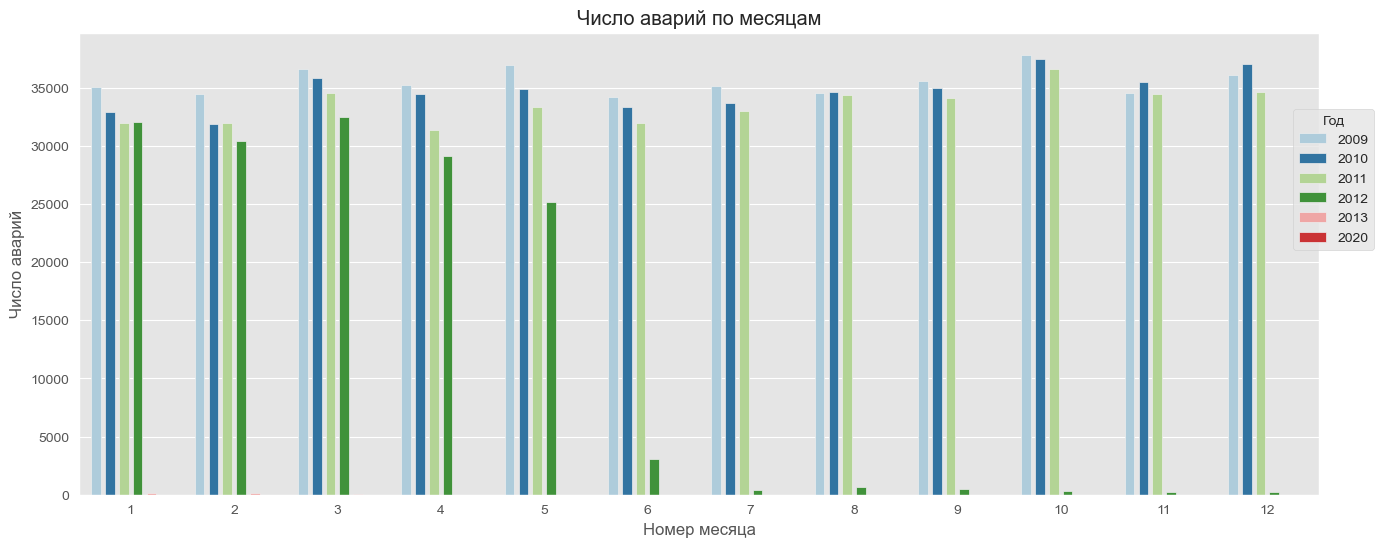

In [21]:
plt.figure(figsize=(16,6))

sns.barplot(data=coll_per_mon, x='month', y='amount_col', hue='year', gap=0.3, palette='Paired')

plt.title('Число аварий по месяцам')
plt.ylabel('Число аварий')
plt.xlabel('Номер месяца')
plt.legend(title='Год', bbox_to_anchor=(1.05, 0.85))
plt.show()

__Вывод:__ обнаружено, что в датасете наиболее полно представлены данные по ДТП за 2009-2011 годы включительно, информации по другим годам значительно меньше. При этом из анализа колебаний количества ДТП по месяцам можно выделить несколько пиков - октябрь, декабрь и март. Это можно объяснить сменой сезона - водители начинают перестраиваться под новый погодный режим, что влечет повышение аварийности на дорогах из-за снежного/влажного покрытия.

### Подготовка аналитических задач

#### Зависимость тяжести ДТП от состояния дорог

Рассмотрим зависимость тяжести ДТП от состояния дорожного покрытия в момент ДТП:

In [22]:
coll_road = pd.read_sql_query(
	'''
SELECT road_surface,
	collision_damage,
	COUNT(*)::numeric / SUM(COUNT(*)) OVER (PARTITION BY road_surface) * 100 AS collision_ratio
FROM collisions
WHERE road_surface IS NOT NULL
GROUP BY road_surface, collision_damage
''',
	con=engine)

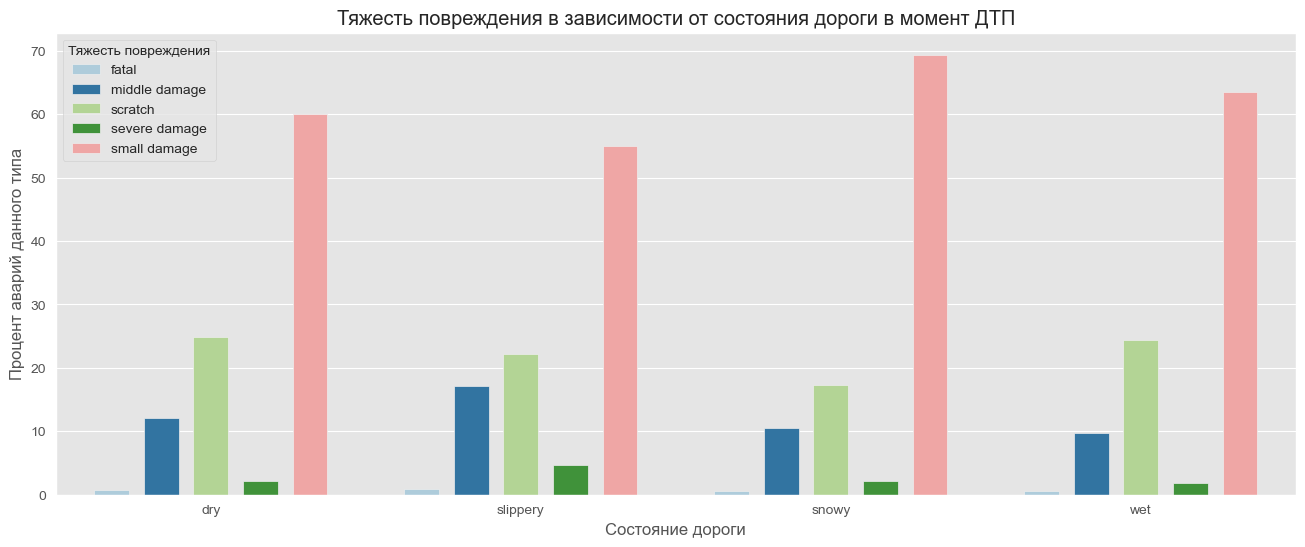

In [23]:
plt.figure(figsize=(16,6))

sns.barplot(data=coll_road, x='road_surface', hue='collision_damage', y='collision_ratio', gap=0.3, palette='Paired')

plt.title('Тяжесть повреждения в зависимости от состояния дороги в момент ДТП')
plt.ylabel('Процент аварий данного типа')
plt.xlabel('Состояние дороги')
plt.legend(title='Тяжесть повреждения')

plt.show()

In [24]:
coll_road_sum = pd.read_sql_query(
	'''
SELECT road_surface,
	COUNT(*)::numeric
FROM collisions
WHERE road_surface IS NOT NULL
GROUP BY road_surface
''',
	con=engine)

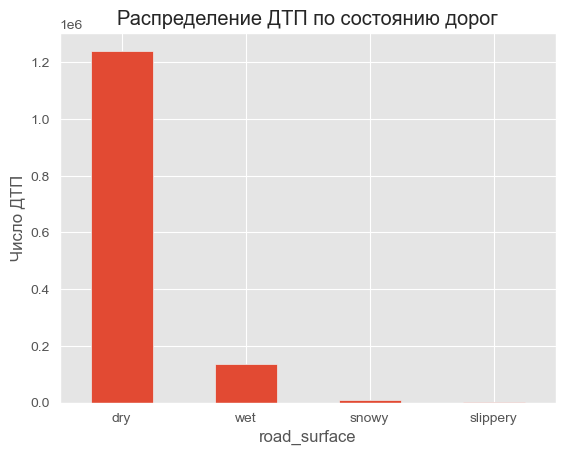

In [25]:
coll_road_sum.sort_values(by='count', ascending=0).plot(kind='bar', x='road_surface', y='count', rot=0, legend=0)

plt.title('Распределение ДТП по состоянию дорог')
plt.ylabel('Число ДТП')

plt.show()

__Вывод:__ большинство ДТП происходит в условиях сухого дорожного покрытия, подавляющее большинство ДТП относятся к легким - независимо от состояния дороги сохраняется одинаковая картина распределения. Наблюдаются лишь небольшие колебания в долях типов повреждения.<br> <br> При снежном и влажном покрытии несколько возрастает доля ДТП с небольшим повреждением относительно сухого покрытия, доля тяжелых ДТП при этом сохраняется такой же. При этом при скользком покрытии видим снижение доли небольших повреждений на фоне роста ДТП средней тяжести и тяжелых ДТП - это может быть обусловлено большей "коварностью" подобных погодных условий и сложностью адаптации к ним.

#### Самые частые причины ДТП

Получим из датасета информацию о том, какая причина аварий является наиболее распространенной:

In [26]:
coll_reason = pd.read_sql_query(
	'''
SELECT pcf_violation_category,
	COUNT(DISTINCT case_id)
FROM collisions
WHERE pcf_violation_category IS NOT NULL
GROUP BY pcf_violation_category
''',
	con=engine)

In [27]:
coll_reason['count'] = round(((coll_reason['count'] / coll_reason['count'].sum()) * 100), 2)
coll_reason = coll_reason.sort_values(by='count', ascending=True)

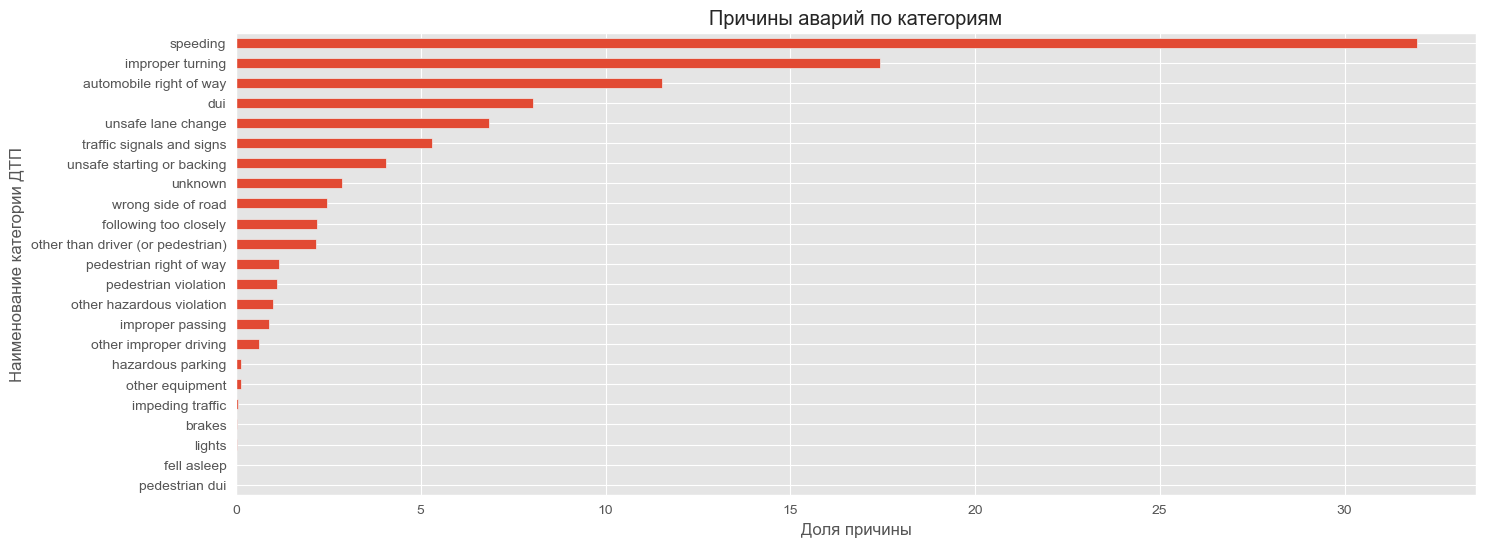

In [28]:
coll_reason.plot(kind='barh', x='pcf_violation_category', figsize=(16,6), legend=0)

plt.title('Причины аварий по категориям')
plt.ylabel('Наименование категории ДТП')
plt.xlabel('Доля причины')
plt.show()

__Вывод:__ мы составили список категорий, к которым относятся ДТП, полученные из датасета. На первом месте (треть от всех аварий) стоит превышение скорости, нарушение правил поворота стоит на втором месте с 17% ото всех происшествий, на третьем месте - нарушение правил приоритета с долей 11,5% от всех случаев

#### Примеры задач

Предложим ряд задач для решения, которые помогут глубже понять данные и их зависимости

Для части задач предложим решения:

##### 1 Задача

__Проанализировать зависимость наличия телефона и виновности в ДТП/степени тяжести повреждения (соединить parties.cellphone_in_use и таблицу collisions).__

In [29]:
coll_phone = pd.read_sql_query(
	'''	
SELECT p.cellphone_in_use,
		c.collision_damage,
		COUNT(*)::numeric / SUM(COUNT(*)) OVER (PARTITION BY p.cellphone_in_use) * 100 AS collision_ratio
FROM parties AS p
LEFT JOIN collisions AS c ON p.case_id=c.case_id
WHERE p.cellphone_in_use IS NOT NULL
GROUP BY p.cellphone_in_use, c.collision_damage
''',
	con=engine)

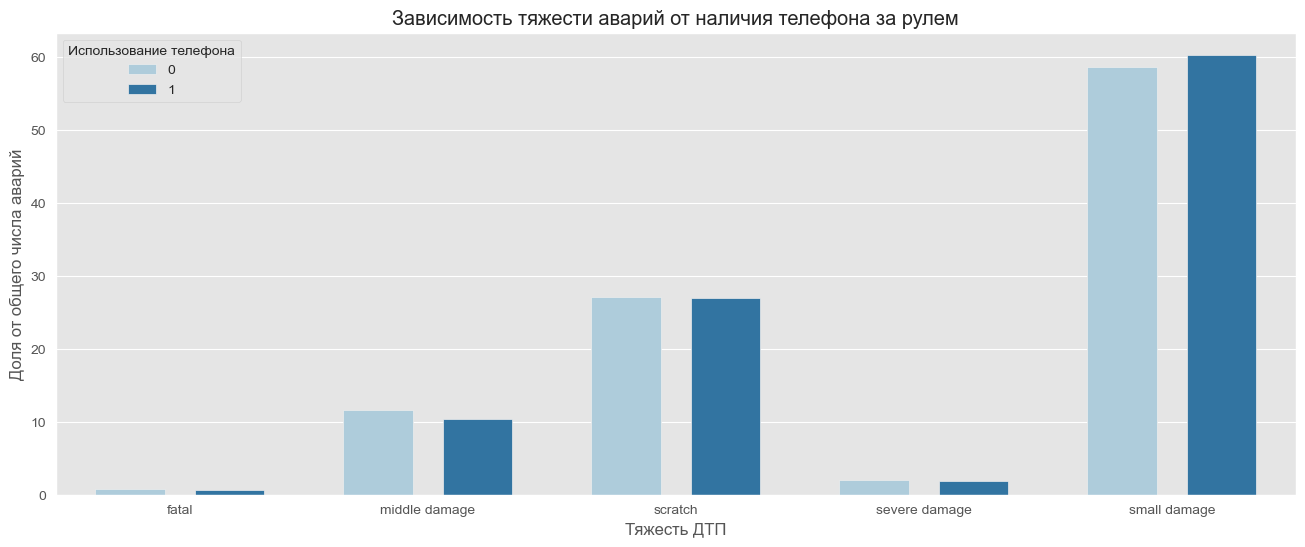

In [30]:
plt.figure(figsize=(16,6))

sns.barplot(data=coll_phone, x='collision_damage', hue='cellphone_in_use', y='collision_ratio', gap=0.3, palette='Paired')


plt.title('Зависимость тяжести аварий от наличия телефона за рулем')
plt.ylabel('Доля от общего числа аварий')
plt.xlabel('Тяжесть ДТП')
plt.legend(title='Использование телефона')

plt.show()

In [31]:
coll_phone_g = pd.read_sql_query(
	'''
SELECT p.cellphone_in_use,
		p.at_fault,
		COUNT(*)::numeric / SUM(COUNT(*)) OVER (PARTITION BY p.cellphone_in_use) * 100 AS collision_ratio
FROM parties AS p
WHERE p.cellphone_in_use IS NOT NULL
GROUP BY p.cellphone_in_use, p.at_fault
''',
	con=engine)

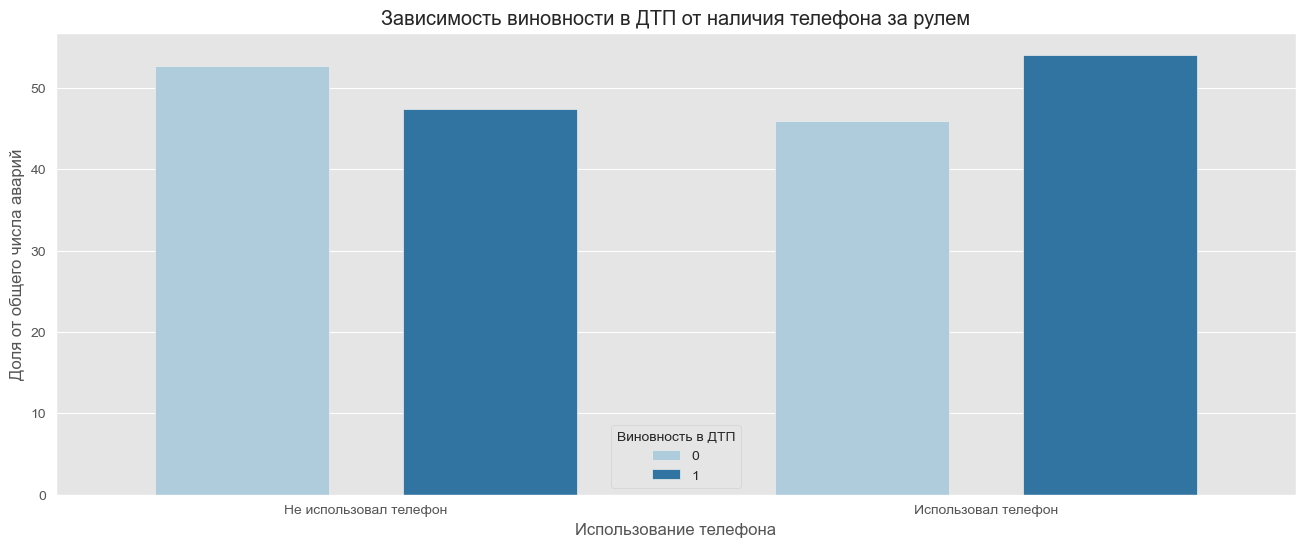

In [32]:
plt.figure(figsize=(16,6))

sns.barplot(data=coll_phone_g, x='cellphone_in_use', hue='at_fault', y='collision_ratio', gap=0.3, palette='Paired')


plt.title('Зависимость виновности в ДТП от наличия телефона за рулем')
plt.ylabel('Доля от общего числа аварий')
plt.xlabel('Использование телефона')
plt.xticks(labels=['Не использовал телефон', 'Использовал телефон'], ticks=[0,1])
plt.legend(title='Виновность в ДТП')

plt.show()

__Вывод:__ согласно полученным нами графикам наблюдается слабая корреляция между использованием телефона и тяжестью повреждений в результате ДТП. Однако при построении зависимости между признанием участника ДТП виновным и использованием телефона имеется связь - пользователи мобильных устройств чаще оказываются виновниками ДТП

##### 2 Задача

__Связать и проанализировать данные о машине и ДТП (таблицы vehicles и collisions). Оценить связь типов КПП и возраста автомобиля с количеством, тяжестью ДТП.__

В первую очередь получим данные о зависимости типа КПП и тяжести повреждений при аварии:

In [33]:
coll_trans = pd.read_sql_query(
	'''
SELECT v.vehicle_transmission,
		c.collision_damage,
		COUNT(*)::numeric / SUM(COUNT(*)) OVER (PARTITION BY v.vehicle_transmission) * 100 AS collision_ratio
FROM vehicles AS v
LEFT JOIN collisions AS c ON v.case_id=c.case_id
WHERE v.vehicle_transmission IS NOT NULL
GROUP BY v.vehicle_transmission, c.collision_damage
''',
	con=engine)

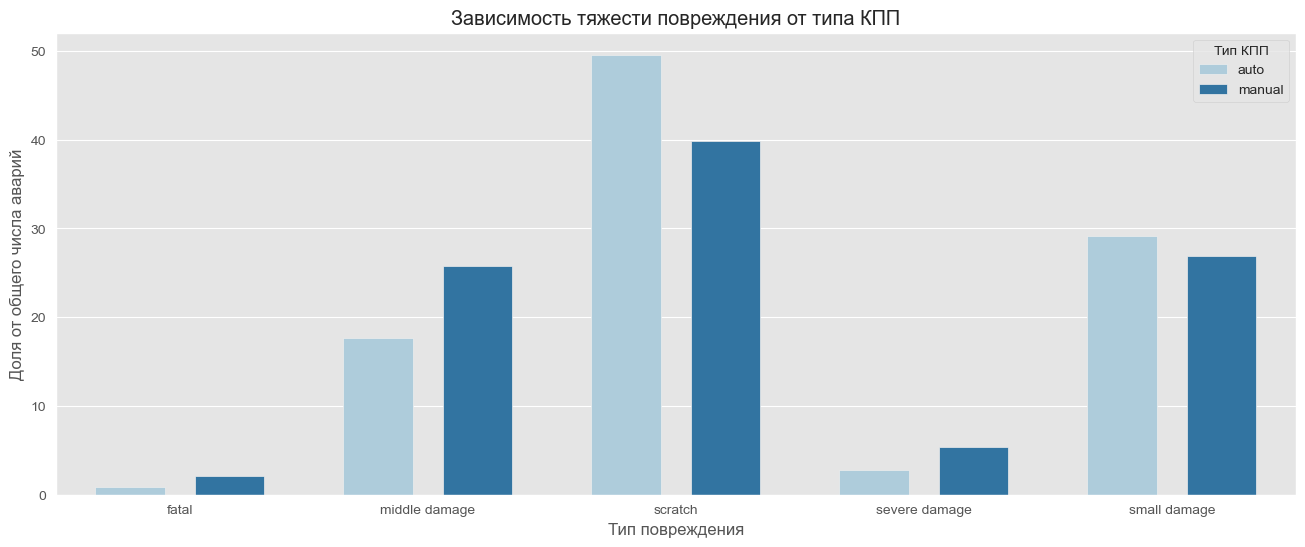

In [34]:
plt.figure(figsize=(16,6))

sns.barplot(data=coll_trans, x='collision_damage', hue='vehicle_transmission', y='collision_ratio', gap=0.3, palette='Paired')


plt.title('Зависимость тяжести повреждения от типа КПП')
plt.ylabel('Доля от общего числа аварий')
plt.xlabel('Тип повреждения')
plt.legend(title='Тип КПП')

plt.show()

Далее строим зависимость тяжести повреждений от возраста авто, разбив перед этим на равные группы

In [35]:
tr = pd.read_sql_query(
	'''
WITH age_group AS (
SELECT v.case_id, c.collision_damage, v.vehicle_age, NTILE(5) OVER (ORDER BY v.vehicle_age)
FROM vehicles AS v
LEFT JOIN collisions AS c ON v.case_id=c.case_id
WHERE vehicle_age IS NOT NULL
)
	
SELECT ntile,
	collision_damage,
	COUNT(*)::numeric / SUM(COUNT(*)) OVER (PARTITION BY  ntile) * 100 AS ratio
FROM age_group
GROUP BY ntile, collision_damage
ORDER BY ntile, ratio DESC
''',
	con=engine)

Возраст автомболилей в группе:

In [36]:
age = pd.read_sql_query(
	'''
WITH tiles AS (
SELECT NTILE(5) OVER (ORDER BY vehicle_age) AS age_tile, vehicle_age
FROM vehicles
WHERE vehicle_age IS NOT NULL
)
	
SELECT age_tile,
	MIN(vehicle_age),
	MAX(vehicle_age)
FROM tiles
GROUP BY age_tile
ORDER BY age_tile ASC
''',
	con=engine)
age

,age_tile,min,max
0,1,0,3
1,2,3,4
2,3,4,6
3,4,6,8
4,5,8,161


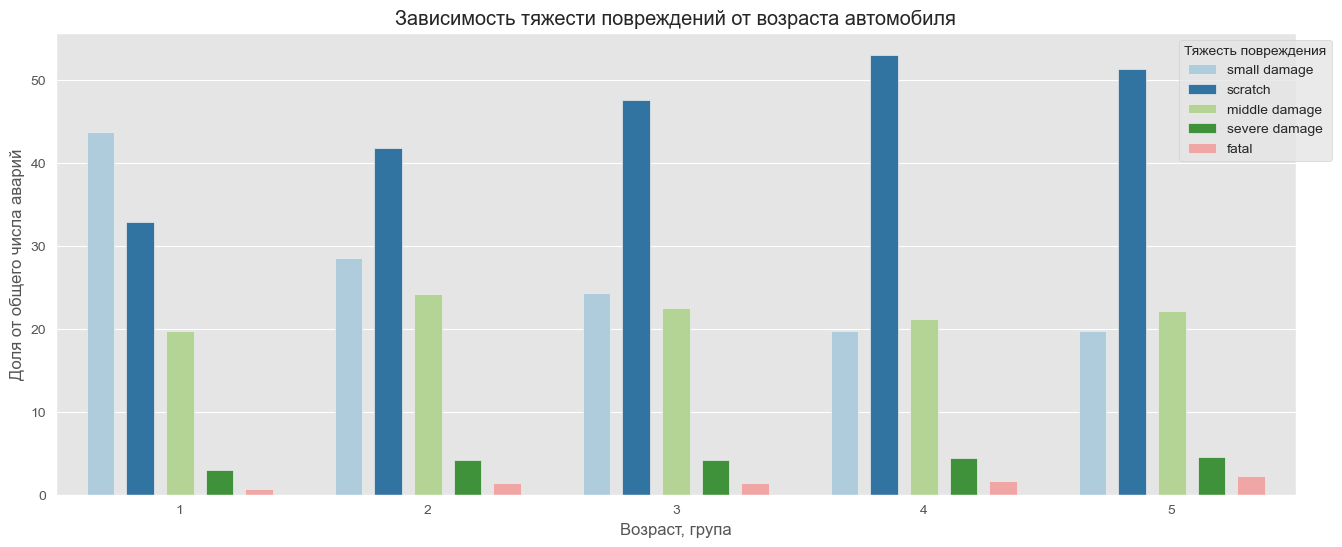

In [37]:
plt.figure(figsize=(16,6))

sns.barplot(data=tr, x='ntile', hue='collision_damage', y='ratio', gap=0.3, palette='Paired')


plt.title('Зависимость тяжести повреждений от возраста автомобиля')
plt.ylabel('Доля от общего числа аварий')
plt.xlabel('Возраст, група')
plt.legend(title='Тяжесть повреждения', bbox_to_anchor=(0.9,1))

plt.show()

__Выводы:__
- однозначно видно, что для автомобилей с механическими коробками характерны более тяжелые аварии, в то время как авто с АКПП чаще получают небольшие повреждения по отношению к МКПП;
- возраст показывает более сложные зависимости: для новых моделей характерна высокая доля небльших повреждений - это можно объяснить более высокими ходовыми и "визуальными" качествами таких авто, что побуждает арендатора к более агрессивному и самоуверенному стилю вождения. При этом, при росте возраста автомобиля не только снижается доля малых повреждений и растет число царапин, но так же сильно (по отношению к новым моделям) растет число тяжелых и фатальных повреждений. Это можно объяснить высокой изношенностью таких автомобилей, что может вызывать дополнительные аварии.

##### 3 Задача

Необходимо проанализировать тяжесть и количество ДТП в зависимости от погодных условий:

In [38]:
coll_weather = pd.read_sql_query(
	'''
SELECT weather_1,
		collision_damage,
		COUNT(*)::numeric / SUM(COUNT(*)) OVER (PARTITION BY weather_1) * 100 AS ratio
FROM collisions
WHERE weather_1 IS NOT NULL
GROUP BY weather_1, collision_damage
ORDER BY COUNT(*)::numeric / SUM(COUNT(*)) OVER (PARTITION BY weather_1) * 100 DESC
''',
	con=engine)

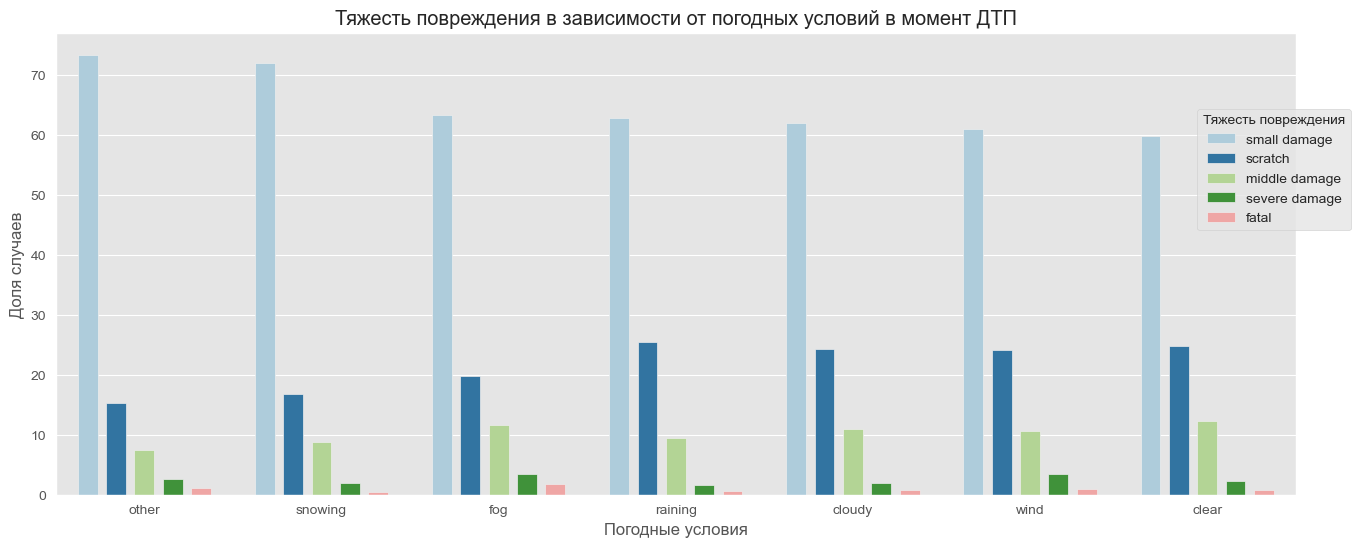

In [39]:
plt.figure(figsize=(16,6))

sns.barplot(data=coll_weather, x='weather_1', hue='collision_damage', y='ratio', gap=0.3, palette='Paired')

plt.title('Тяжесть повреждения в зависимости от погодных условий в момент ДТП')
plt.ylabel('Доля случаев')
plt.xlabel('Погодные условия')
plt.legend(title='Тяжесть повреждения', bbox_to_anchor=(1.05, 0.85))

plt.show()

In [40]:
coll_weather_sum = pd.read_sql_query(
	'''
SELECT weather_1,
		COUNT(*)::numeric
FROM collisions
WHERE weather_1 IS NOT NULL
GROUP BY weather_1
''',
	con=engine)

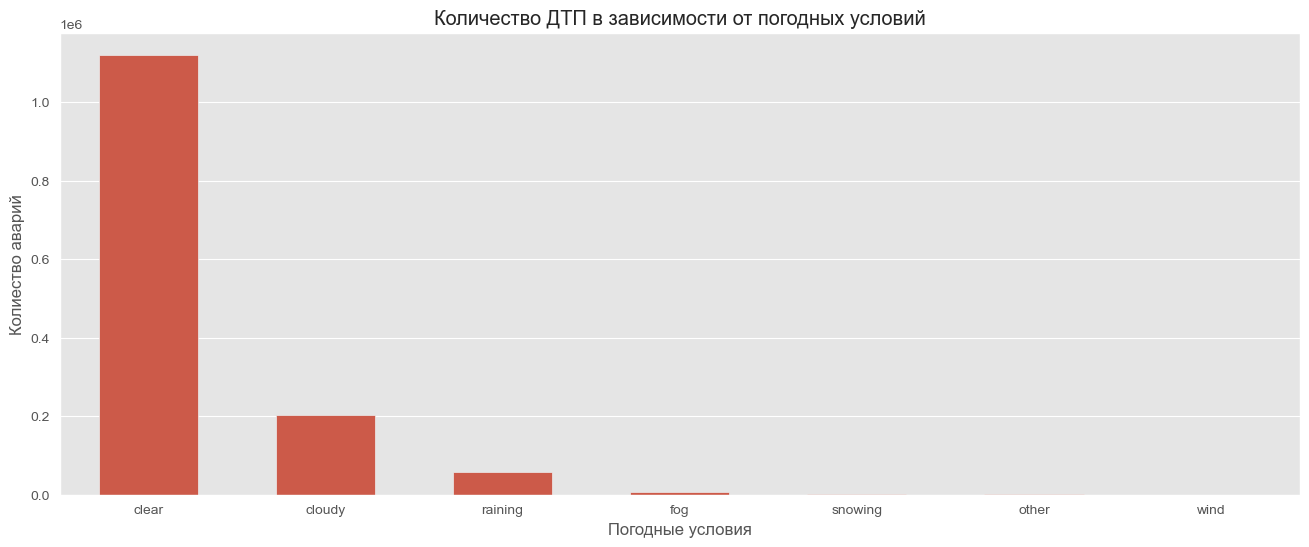

In [41]:
plt.figure(figsize=(16,6))

sns.barplot(data=coll_weather_sum.sort_values(by='count', ascending=False), x='weather_1', y='count', gap=0.3)

plt.title('Количество ДТП в зависимости от погодных условий')
plt.ylabel('Колиество аварий')
plt.xlabel('Погодные условия')

plt.show()

__Вывод:__ распределение во многом похоже на зависимость ДТП от состояния дорожного покрытия (что объясняется их взаимосвязью). Большая часть аварий произошла в ясную погоду, при этом независимо от погодных условий большая часть повреждений при ДТП относится к легким. Также в туманную и ветреную погоду наблюдаем почти двукратный рост тяжелых ДТП, однако их доля всё так же остается низкой.

##### 4 Задача

Проанализировать взаимосвязь трезвости участника ДТП и его виновности:

In [42]:
coll_sobr = pd.read_sql_query(
	'''
SELECT party_sobriety,
		AVG(at_fault) * 100 AS fault_ratio
FROM parties
WHERE party_sobriety IS NOT NULL
GROUP BY party_sobriety
''',
	con=engine)

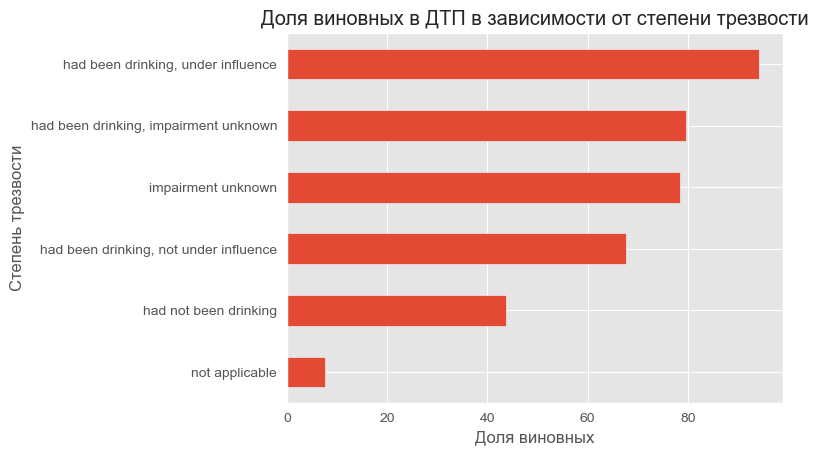

In [43]:
coll_sobr.sort_values(by='fault_ratio').plot(kind='barh', x='party_sobriety', y='fault_ratio', legend=0)

plt.title('Доля виновных в ДТП в зависимости от степени трезвости')
plt.ylabel('Степень трезвости')
plt.xlabel('Доля виновных')

plt.show()

Посмотрим, в каком состоянии находились виновные в ДТП:

In [44]:
coll_sobr2 = pd.read_sql_query(
	'''
SELECT party_sobriety,
		COUNT(*)::numeric / (SELECT COUNT(*) FROM parties WHERE at_fault=1) * 100 AS fault_ratio
FROM parties
WHERE at_fault=1 AND party_sobriety IS NOT NULL
GROUP BY party_sobriety
''',
	con=engine).sort_values(by='fault_ratio')

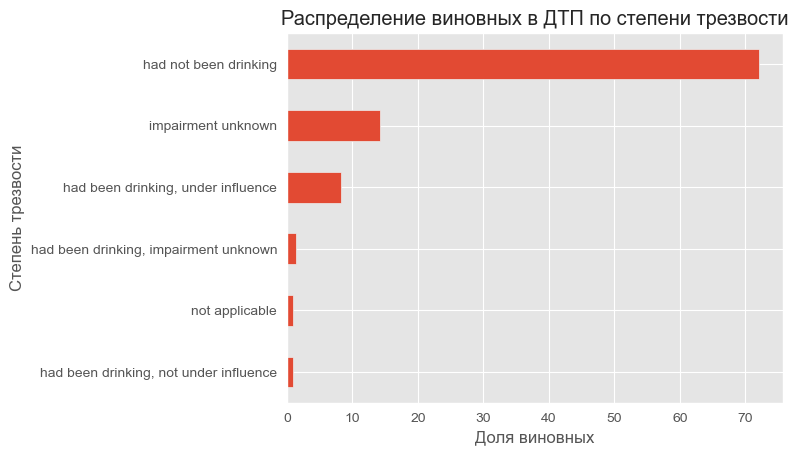

In [45]:
coll_sobr2.plot(kind='barh', x='party_sobriety', y='fault_ratio', legend=0)

plt.title('Распределение виновных в ДТП по степени трезвости')
plt.ylabel('Степень трезвости')
plt.xlabel('Доля виновных')

plt.show()

__Вывод:__ большая часть водителей, признанных виновными, находилась в трезвом состоянии. Однако при этом среди трезвых водителей-участников ДТП только 40% было признано виновным, в то время как среди выпивавших в той или иной степени это число доходит до 80%. Такое соотношение чисел говорит в первую очередь о том, что большинство водителей на дороге - трезвые, соответственно и большинство участников ДТП. Но среди находищхся в опьяненном состоянии шанс быть виновником аварии возрастает до крайне высоких значений.

__Остальные примеры задач для рассмотрения коллегам:__

##### 5 Задача

Оценить время происшествия: оценить распределение ДТП по времени суток (утро, день, ночь) - таблица collisions.

##### 6 Задача

Оценить степень ответственности арендаторов - свзять сумму страховки (допускается категоризировать этот признак) и виновность в ДТП, количество ДТП.

## Подготовка данных для выполнения модели

### Загрузка данных и отбор признаков

Из базы данных заказчика отберем данные согласно ТЗ и те, которые по нашему мнению будут полезны для обучения моделей:

In [46]:
data = pd.read_sql_query(
	'''
SELECT c.weather_1,
		c.road_surface,
		c.road_condition_1,
		c.lighting,
		c.county_city_location,
		c.control_device,
		c.intersection,
		DATE_PART('dow', c.collision_date) AS day_of_week,
		DATE_PART('hour', c.collision_time) AS hour,
		v.vehicle_type,
		v.vehicle_transmission,
		v.vehicle_age,
		p.insurance_premium,
		p.cellphone_in_use,
		p.at_fault
FROM parties AS p
INNER JOIN collisions AS c ON p.case_id=c.case_id INNER JOIN vehicles AS v ON p.case_id=v.case_id AND p.party_number=v.party_number
WHERE p.party_type='car' AND c.collision_damage != 'scratch' AND DATE_PART('year', collision_date)='2012'
''',
	con=engine)
data

,weather_1,road_surface,road_condition_1,lighting,county_city_location,control_device,intersection,day_of_week,hour,vehicle_type,vehicle_transmission,vehicle_age,insurance_premium,cellphone_in_use,at_fault
0,clear,dry,normal,dark with street lights,3711,none,0.0,5.0,1.0,sedan,manual,3.0,NaN,0.0,1
1,clear,dry,normal,dark with street lights,0708,functioning,0.0,0.0,2.0,sedan,manual,10.0,54.0,0.0,0
2,NaN,NaN,NaN,NaN,2002,functioning,1.0,4.0,11.0,sedan,auto,10.0,67.0,0.0,0
3,cloudy,dry,normal,dusk or dawn,0109,none,0.0,5.0,18.0,sedan,auto,5.0,41.0,0.0,0
4,clear,dry,normal,daylight,3345,functioning,0.0,3.0,12.0,sedan,auto,12.0,79.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56243,clear,dry,normal,daylight,3700,none,0.0,5.0,7.0,coupe,auto,8.0,54.0,0.0,1
56244,clear,dry,normal,daylight,3700,none,0.0,0.0,15.0,coupe,manual,4.0,28.0,0.0,1
56245,clear,dry,normal,daylight,3500,none,0.0,6.0,12.0,coupe,manual,6.0,39.0,0.0,1
56246,clear,dry,normal,daylight,1942,none,0.0,2.0,17.0,coupe,auto,6.0,41.0,0.0,0


Данные признаки были выбраны по следующим причинам:
- данные об окружающей среде, которые можно отслеживать в ходе поездки (weather_1, road_surface, road_condition_1, lighting) и которые влияют на риск ДТП;
- характеристики автомобиля (vehicle_transmission, vehicle_age) непосредственно влияют на вождение и вероятность и тяжесть ДТП;
- информация о маршруте - intersection, county_city_location;
- информация о водителе, которую так же можно в определенном объеме контролировать (cellphone_in_use);
- целевой признак at_fault.<br>
  Отбирались признаки, не содержащие информацию об уже свершенной аварии для избежания утечки данных.

In [47]:
df = data.copy()

Группы признаков

In [48]:
df.columns

Index(['weather_1', 'road_surface', 'road_condition_1', 'lighting',
       'county_city_location', 'control_device', 'intersection', 'day_of_week',
       'hour', 'vehicle_type', 'vehicle_transmission', 'vehicle_age',
       'insurance_premium', 'cellphone_in_use', 'at_fault'],
      dtype='str')

In [49]:
cat_features = ['weather_1', 'road_surface', 'road_condition_1', 'lighting',
				'control_device', 'intersection', 'day_of_week',
				'hour', 'vehicle_type', 'vehicle_transmission', 'cellphone_in_use']

In [50]:
# номер района укажем в числовых признаках ввиду большого числа параметров, в случае проблем с обучением возможно кодирование TargetEncoder'ом
num_features = ['vehicle_age', 'insurance_premium', 'county_city_location']

### Предобработка

Произведем подготовку данных для анализа и моделирования.

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 56248 entries, 0 to 56247
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   weather_1             56080 non-null  str    
 1   road_surface          55900 non-null  str    
 2   road_condition_1      55999 non-null  str    
 3   lighting              56094 non-null  str    
 4   county_city_location  56248 non-null  str    
 5   control_device        56033 non-null  str    
 6   intersection          56073 non-null  float64
 7   day_of_week           56248 non-null  float64
 8   hour                  56160 non-null  float64
 9   vehicle_type          56248 non-null  str    
 10  vehicle_transmission  55389 non-null  str    
 11  vehicle_age           54554 non-null  float64
 12  insurance_premium     55701 non-null  float64
 13  cellphone_in_use      51777 non-null  float64
 14  at_fault              56248 non-null  int64  
dtypes: float64(6), int64(1), str(8

Данные находятся в соответствующих им типах

#### Дубликаты

In [52]:
df['weather_1'].unique()

<ArrowStringArray>
['clear', nan, 'cloudy', 'raining', 'fog', 'snowing', 'other', 'wind']
Length: 8, dtype: str

In [53]:
df['road_condition_1'].unique()

<ArrowStringArray>
[        'normal',              nan,   'construction',    'obstruction',
          'holes',          'other',        'flooded', 'loose material',
  'reduced width']
Length: 9, dtype: str

In [54]:
df['lighting'].unique()

<ArrowStringArray>
[                'dark with street lights',
                                       nan,
                            'dusk or dawn',
                                'daylight',
              'dark with no street lights',
 'dark with street lights not functioning']
Length: 6, dtype: str

In [55]:
df['control_device'].unique()

<ArrowStringArray>
['none', 'functioning', nan, 'obscured', 'not functioning']
Length: 5, dtype: str

Среди категориальных признаков не обнаружено дубликатов

#### Пропуски

In [56]:
df.isna().sum()

weather_1                168
road_surface             348
road_condition_1         249
lighting                 154
county_city_location       0
control_device           215
intersection             175
day_of_week                0
hour                      88
vehicle_type               0
vehicle_transmission     859
vehicle_age             1694
insurance_premium        547
cellphone_in_use        4471
at_fault                   0
dtype: int64

Учитывая невысокое число пропусков, удалим их из датасета

In [57]:
(df.shape[0]- df.dropna().shape[0]) / df.shape[0] * 100

13.211136395960747

In [58]:
df = df.dropna()

### EDA

Необходимые функции:

In [59]:
def cat_bar_plot(data, stat_name, size=(6,5), title='1'):
	plt.figure(figsize=size)

	sns.countplot(data=data, y=stat_name, stat='percent', order=data[stat_name].value_counts().index)
	
	(plt.title(stat_name) if title=='1' else plt.title(title))
plt.show()

In [60]:
def round_graph(data, stat_name):
	data.groupby(by=stat_name).agg({stat_name: 'count'}).plot(kind='pie',
											y=stat_name,
											autopct='%1.1f%%',
											title=stat_name,
											legend=False,
										   )
	
	plt.axis('off')
	plt.show()

Рассмотрим распределение некоторых признаков:

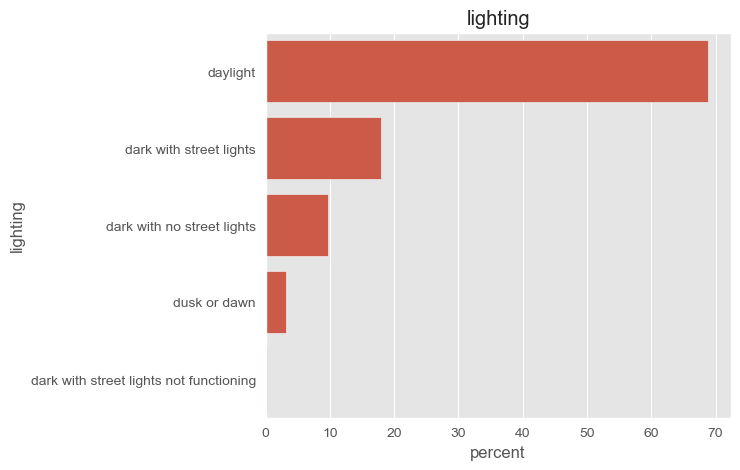

In [61]:
cat_bar_plot(df, 'lighting')

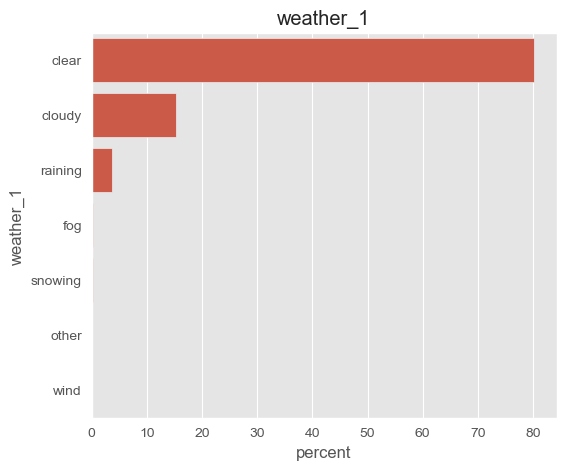

In [62]:
cat_bar_plot(df, 'weather_1')

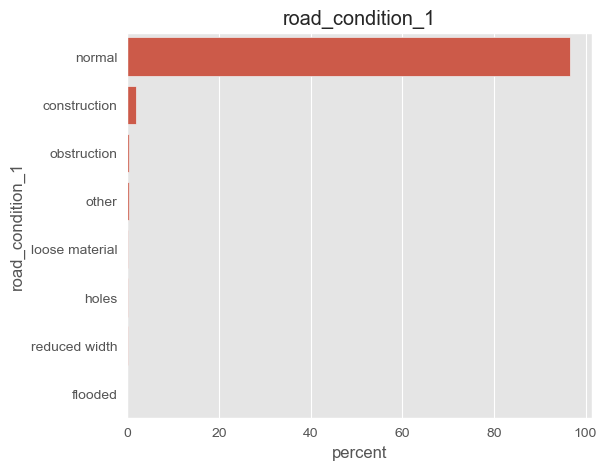

In [63]:
cat_bar_plot(df, 'road_condition_1')

Число аварий чуть возрастает по пятницам и субботам - люди спешат с работы на отдых / за город.

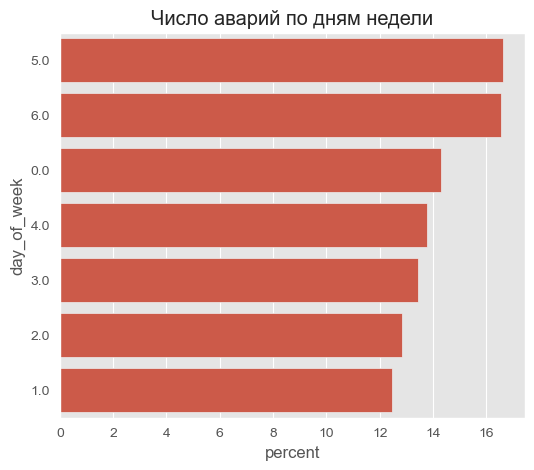

In [64]:
cat_bar_plot(df, 'day_of_week', title='Число аварий по дням недели')

Интенсивность аварий возрастает в вечернее время

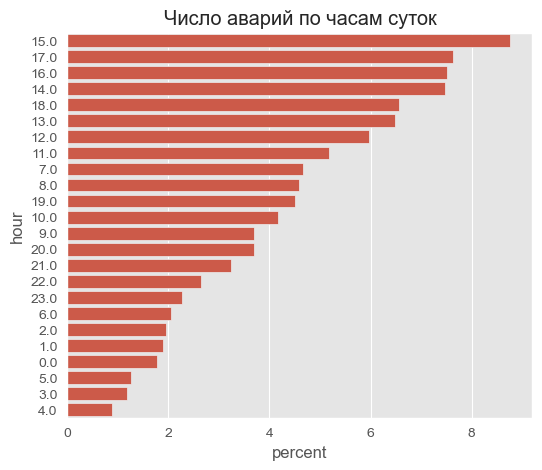

In [65]:
cat_bar_plot(df, 'hour', title='Число аварий по часам суток')

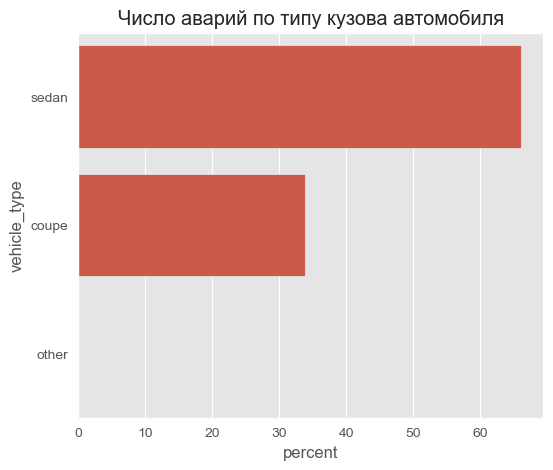

In [66]:
cat_bar_plot(df, 'vehicle_type', title='Число аварий по типу кузова автомобиля')

Распределение суммы страховки:

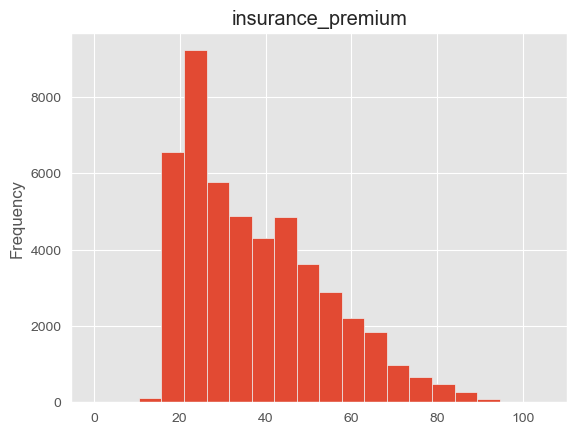

In [67]:
df['insurance_premium'].plot(kind='hist', bins=20, title='insurance_premium')

plt.show()

В возрасте имеем выброс:

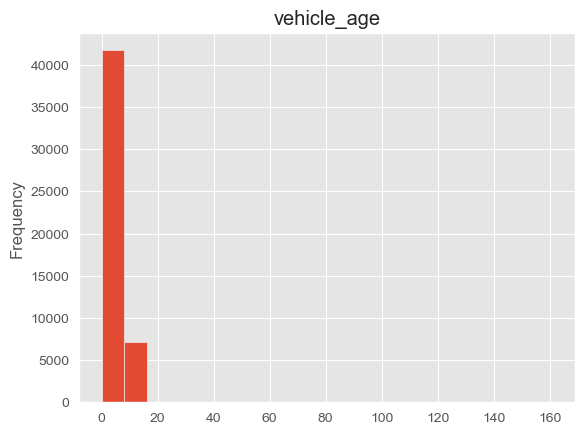

In [68]:
df['vehicle_age'].plot(kind='hist', bins=20, title='vehicle_age')

plt.show()

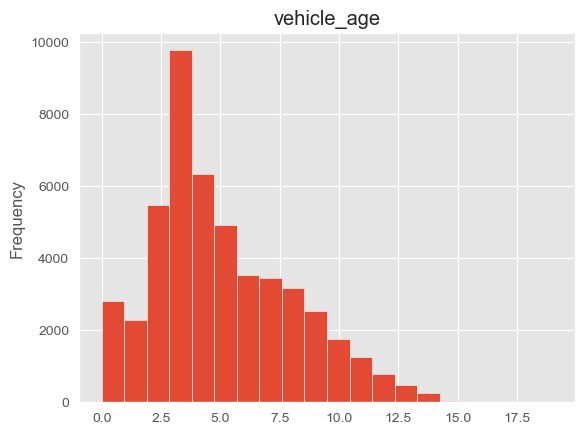

In [69]:
df.loc[df['vehicle_age'] <= 160, ['vehicle_age']].plot(kind='hist', bins=20, title='vehicle_age', legend=0)


plt.show()

In [70]:
df = df.loc[df['vehicle_age'] <= 160]

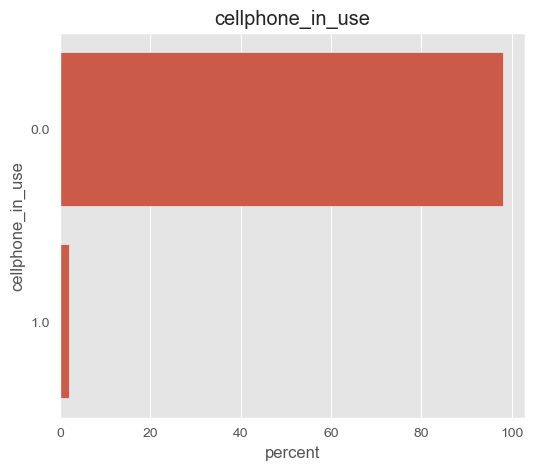

In [71]:
cat_bar_plot(df, 'cellphone_in_use')

Имеем данные, не описанные заказчиком. В реальной ситуации необходимо обратиться за пояснением к признаку. Не имея такой возможности, предположим что признак характеризует работу телефона с приложением для аренды.

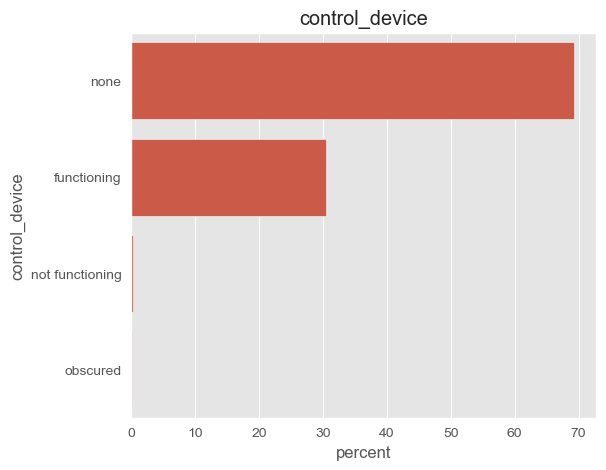

In [72]:
cat_bar_plot(df, 'control_device')

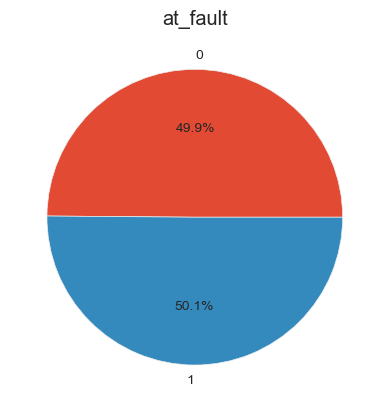

In [73]:
round_graph(df, 'at_fault')

### Анализ корреляции

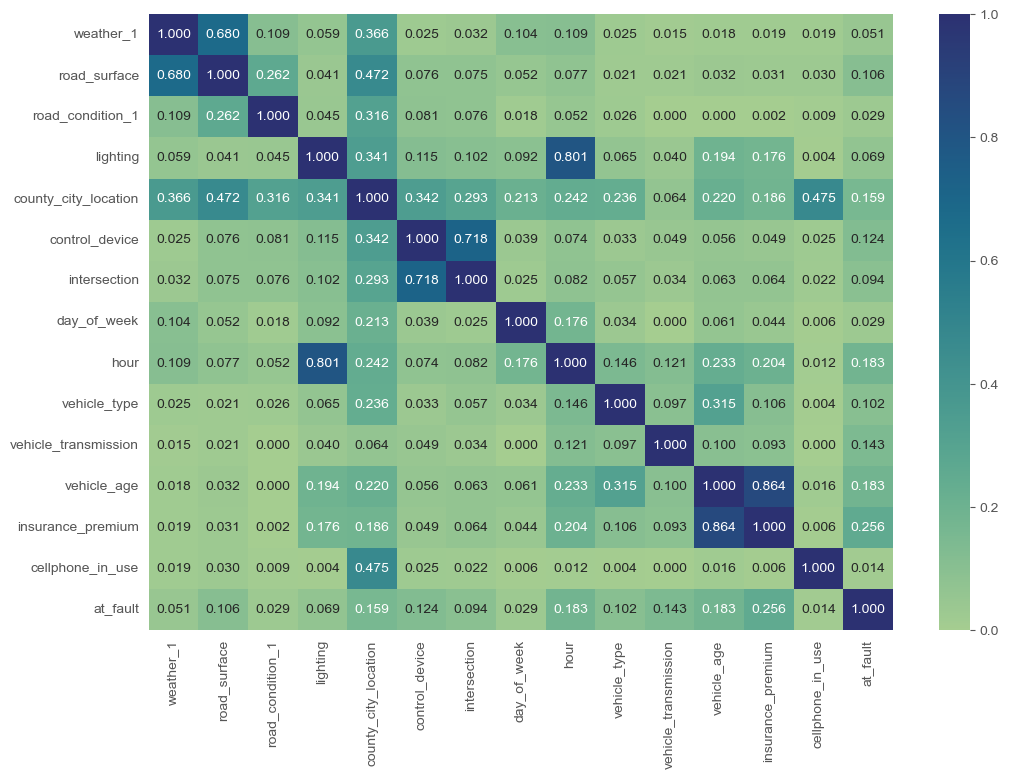

In [74]:
plt.figure(figsize=(12,8))

sns.heatmap(df.phik_matrix(verbose=False), annot=True, fmt='.3f', cmap='crest')

plt.show()

Между входными признаками наблюдается мультиколлинеарность. Weather_1 почти не коррелирует с целевым, при этом обладает высокой корреляцией с road_surface, который в свою очередь имеет более высокую корреляцию. Так же время ДТП напрямую связано с признаком lighting, который в свою очередь практически не коррелирует с целевым. Обе пары логически связаны друг с другом и по сути дублируют информацию. Исключим эти признаки чтобы снизить мультиколлинеарность итак неидеального датасета.

In [75]:
df = df.drop(['weather_1', 'lighting'], axis=1)

In [76]:
cat_features.remove('weather_1')
cat_features.remove('lighting')

__Выводы:__ мы провели подготовку данных в части обработки дубликатов и пропусков и рассмотрели распределения данных. Из графиков видим, что большинство ДТП происходило в одних и тех же условиях - ясная погода, чистое дорожное покрытие и т.д. Практически все признаки слабо коррелируют с целевым, так же была выявлена мультиколлинеарность входных признаков. Так как они логически связаны друг с другом было решено исключить часть из них. Эти факторы усложнят работу модели, т.к. ей будет тяжело отделить одни признаки от других и могут сильно повлиять на дальнейшее моделирование.

### Подготовка данных

In [77]:
RANDOM_STATE = 42

In [78]:
def data_split(data, target='at_fault', RANDOM_STATE = RANDOM_STATE, TEST_SIZE = 0.25, shuffle=True):
	X_train, X_test, y_train, y_test = train_test_split(
		data.drop(target, axis=1),
		data[target],
		test_size = TEST_SIZE, 
		random_state = RANDOM_STATE,
        shuffle=shuffle
	)
	return X_train, X_test, y_train, y_test

In [79]:
X_train, X_test, y_train, y_test = data_split(df)

In [80]:
test_ind = y_test.index

Произведем кодирование признаков:

In [81]:
ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

In [82]:
ohe.fit(X_train[cat_features])
ohe_col_names = ohe.get_feature_names_out()

In [83]:
X_train[ohe_col_names] = ohe.transform(X_train.copy()[cat_features])
X_test[ohe_col_names] = ohe.transform(X_test.copy()[cat_features])
X_train = X_train.copy().drop(cat_features, axis=1)
X_test = X_test.copy().drop(cat_features, axis=1)

In [84]:
scaler = StandardScaler()

In [85]:
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

## Выполнение моделей

In [86]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

Необходимые функции:

In [87]:
def summaries_classification(y, y_pred, mod_name='Название модели'):
	chars = [
		accuracy_score(y, y_pred),
		recall_score(y, y_pred, pos_label=1),
		precision_score(y, y_pred, pos_label=1),
		f1_score(y, y_pred, pos_label=1)
	]
			
	return pd.DataFrame(
		data=chars,
		index=['Accuracy(Точность)', 'Recall(Полнота)', 'Precision(Прецизионность)', 'F1-score(F1-мера)'],
		columns=[mod_name])

### Dummy model

Для проверки адекватности модели используем модель, дающую предсказания, повторяющие распределение целевого признака в тренировочном датасете:

In [88]:
check_model = DummyClassifier(strategy='stratified')

In [89]:
check_model.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'stratified'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [90]:
check_result = check_model.predict(y_test)
check_result_proba = check_model.predict_proba(y_test)[:,1]

In [91]:
sum_dum = summaries_classification(y_test, check_result, mod_name='Наивная модель(стратификация)')
sum_dum

,Наивная модель(стратификация)
Accuracy(Точность),0.491314
Recall(Полнота),0.498445
Precision(Прецизионность),0.492002
F1-score(F1-мера),0.495202


Это будет исходными метриками для нас.

В решении задачи ключевыми для нас являются метрики "Полнота" и "Прецизионность". Для нас важно определить всех потенциальных виновников аварии, исходя из гуманистических и финансовых соображений, однако так же нельзя относить каждый прогноз к положительному классу в связи с затратами на ложное предупреждение и потенциальными убытками. Таким образом, ориентироваться будем на среднее гармоническое метрик, т.е. f1-меру.

### Дерево принятия решений

Используем рандомизированную кросс-валидацию для поиска параметров модели:

In [92]:
param_grid = {
		'max_depth': range(2, 14, 2),
		'max_features': range(2, 14, 2),
		'min_samples_leaf': range(1, 10)
	}

In [93]:
randomized_search = RandomizedSearchCV(
	DecisionTreeClassifier(random_state=RANDOM_STATE), 
	param_grid, 
	cv=10,
	n_iter=12,
	scoring='f1',
	random_state=RANDOM_STATE,
	n_jobs=-1,
	error_score='raise'
)

In [94]:
randomized_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': range(2, 14, 2), 'max_features': range(2, 14, 2), 'min_samples_leaf': range(1, 10)}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",12
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default

Лучшая метрика:

In [95]:
randomized_search.best_score_

np.float64(0.6177751705155953)

Гиперпараметры:

In [96]:
randomized_search.best_params_

{'min_samples_leaf': 7, 'max_features': 6, 'max_depth': 6}

Сохраним лучшую модель

In [97]:
best_tree = randomized_search.best_estimator_

### Бустинг

Произведем перебор гиперпараметров для модели градиентного бустинга:

In [98]:
param_grid_boost = {
		'iterations': range(10, 210, 20),
		'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.15, 0.3],
		'depth': range(2, 16, 2)
	}

In [99]:
randomized_search_boost = RandomizedSearchCV(
	CatBoostClassifier(loss_function="Logloss", verbose=0),
	param_grid_boost,
	cv=10,
	n_iter=12,
	scoring='f1',
	random_state=RANDOM_STATE,
	n_jobs=-1,
	error_score='raise'
)

In [100]:
randomized_search_boost.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","CatBoostClass...s', verbose=0)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'depth': range(2, 16, 2), 'iterations': range(10, 210, 20), 'learning_rate': [0.001, 0.01, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",12
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` defau

Лучшая метрика:

In [101]:
randomized_search_boost.best_score_

np.float64(0.6317093069621328)

Гиперпараметры:

In [102]:
randomized_search_boost.best_params_

{'learning_rate': 0.001, 'iterations': 110, 'depth': 2}

Сохраним лучшую модель

In [103]:
best_boost = randomized_search_boost.best_estimator_

### Нейронная сеть

Приведем данные в нужный вид, создадим валидационную выборку:

In [104]:
X_train_s, X_val, y_train_s, y_val = data_split(pd.concat([X_train, y_train], axis=1))

In [105]:
X_train_nn = torch.FloatTensor(X_train.copy().values)
X_train_s_nn = torch.FloatTensor(X_train_s.copy().values)
X_val_nn = torch.FloatTensor(X_val.copy().values)
X_test_nn = torch.FloatTensor(X_test.copy().values)

C:\Users\Tomat\AppData\Local\Temp\ipykernel_7528\2723821602.py:1: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  X_train_nn = torch.FloatTensor(X_train.copy().values)


In [106]:
y_train_nn = torch.FloatTensor(y_train.copy().values)
y_train_s_nn = torch.FloatTensor(y_train_s.copy().values)
y_val_nn = torch.FloatTensor(y_val.copy().values)
y_test_nn = torch.FloatTensor(y_test.copy().values)

При обучении будем использовать проверку метрики по валидационной выборке и на основании этого контролировать обучение.

Функция для инициализации архитектуры и параметров нейросети:

In [107]:
def init_model(
	lr,
	first_drop,
	second_drop,
):

	n_in_neurons = 50
	n_hidden_neurons_1 = 40
	n_hidden_neurons_2 = 20
	n_hidden_neurons_3 = 40
	n_hidden_neurons_4 = 10
	n_out_neurons = 1

	neur_net = nn.Sequential(
		nn.Linear(n_in_neurons, n_hidden_neurons_1),
		nn.ReLU(),
		nn.Dropout(p=first_drop),
		nn.Linear(n_hidden_neurons_1, n_hidden_neurons_2),
		nn.ReLU(),
		nn.Linear(n_hidden_neurons_2, n_hidden_neurons_3),
		nn.ReLU(),
		nn.Dropout(p=second_drop),
		nn.Linear(n_hidden_neurons_3, n_hidden_neurons_4),
		nn.ReLU(),
		nn.Linear(n_hidden_neurons_4, n_out_neurons),
		nn.Sigmoid()
	)
	def init_weights(layer):
		if type(layer) == nn.Linear:
			nn.init.kaiming_uniform_(layer.weight)
			nn.init.normal_(layer.bias, mean=0, std=1)

	neur_net.apply(init_weights)

	optimizer = torch.optim.AdamW(neur_net.parameters(), lr=lr, weight_decay=0.01)

	loss = nn.BCELoss()

	return neur_net, optimizer, loss

Функция для обучения нейросети выбранной архитектуры и с заданным набором гиперпараметров

In [108]:
def model_learn(X_train, X_val, y_train, y_val, lr, first_drop, second_drop, batch_size, eval_count=20, num_epochs=100, accumulation_iteration=4):
	
	torch.manual_seed(42)
	np.random.seed(42)
	random.seed(42)
	
	neur_net, optimizer, loss = init_model(
		lr=lr,
		first_drop=first_drop,
		second_drop=second_drop
	)

	f1_best=-100
	patience=2
	counter=0
		
	num_batches = math.ceil(len(X_train)/batch_size)

	for epoch in range(num_epochs):
		order = np.random.permutation(len(X_train))
		optimizer.zero_grad()

		for batch_i in range(num_batches):
			start_index = batch_i * batch_size
			
			batch_indexes = order[start_index:start_index+batch_size]
			X_batch = X_train[batch_indexes]
			y_batch = y_train[batch_indexes]
		
			preds = neur_net.forward(X_batch).flatten()
					
			loss_value = loss(preds, y_batch) / accumulation_iteration
			loss_value.backward()
			
			if ((batch_i + 1) % accumulation_iteration == 0) or (batch_i + 1 == num_batches):
				optimizer.step()
				optimizer.zero_grad()

		# в метриках используем валидационную выборку
			
		if (epoch + 1) % eval_count == 0 or epoch == num_epochs - 1:
			neur_net.eval()
			
			val_preds = neur_net.forward(X_val).flatten()
			f1 = f1_score(y_val, torch.round(val_preds).detach().numpy())

			#Реализуем раннюю остановку, сохраняем данные лучшего обучения
		
			if f1 > f1_best:
				f1_best = f1
				best_weights = copy.deepcopy(neur_net.state_dict())
				counter = 0	
			else:
				counter += 1
				if counter >= patience:
					print(f'Early stop, эпоха {epoch}\nСнижение метрики на протяжение {counter} вычислений метрики')
					break
	
	neur_net.load_state_dict(best_weights)

	return f1_best, neur_net

Перечень гиперпараметров:

In [109]:
param_grid = {
	'first_drop':[0, 0.1, 0.2],
	'second_drop':[0, 0.1, 0.2],
	'batch_size':[128, 256],
	'lr':[1e-4, 1e-3]
}

Перемешаем в случайном порядке:

In [110]:
random.seed(42)
param_list = list(ParameterGrid(param_grid))
random.shuffle(param_list)

Проведем обучение на 100 эпохах с набором случайных гиперпараметров:

In [111]:
data.shape

(56248, 15)

In [112]:
X_train.shape

(36611, 50)

In [113]:
X_train_s_nn.shape

torch.Size([27458, 50])

In [114]:
f1_best_total = -100

for params in param_list[:10]:

	f1_total, net = model_learn(
						X_train_s_nn,
						X_val_nn,
						y_train_s_nn,
						y_val_nn,
						first_drop=params['first_drop'],
						second_drop=params['second_drop'],
						batch_size=params['batch_size'],
						lr=params['lr']
									 )

	if f1_total > f1_best_total:
		f1_best_total = f1_total
		net_best = net
		best_params = params

Early stop, эпоха 59
Снижение метрики на протяжение 2 вычислений метрики
Early stop, эпоха 79
Снижение метрики на протяжение 2 вычислений метрики
Early stop, эпоха 59
Снижение метрики на протяжение 2 вычислений метрики
Early stop, эпоха 79
Снижение метрики на протяжение 2 вычислений метрики
Early stop, эпоха 59
Снижение метрики на протяжение 2 вычислений метрики
Early stop, эпоха 59
Снижение метрики на протяжение 2 вычислений метрики
Early stop, эпоха 59
Снижение метрики на протяжение 2 вычислений метрики


Итоговая лучшая метрика:

In [115]:
f1_best_total

0.664637857577602

Гиперпараметры:

In [116]:
best_params

{'batch_size': 128, 'first_drop': 0, 'lr': 0.001, 'second_drop': 0.2}

Лучшая модель:

In [117]:
net_best

Sequential(
  (0): Linear(in_features=50, out_features=40, bias=True)
  (1): ReLU()
  (2): Dropout(p=0, inplace=False)
  (3): Linear(in_features=40, out_features=20, bias=True)
  (4): ReLU()
  (5): Linear(in_features=20, out_features=40, bias=True)
  (6): ReLU()
  (7): Dropout(p=0.2, inplace=False)
  (8): Linear(in_features=40, out_features=10, bias=True)
  (9): ReLU()
  (10): Linear(in_features=10, out_features=1, bias=True)
  (11): Sigmoid()
)

### Сравнение моделей

Сравнительная таблица метрики моделей:

In [118]:
pd.DataFrame(
	data=[[float(randomized_search.best_score_), float(randomized_search_boost.best_score_), f1_best_total]],
	index=['F1-мера'],
	columns=['Дерево принятия решений', 'Градиентный бустинг', 'Нейросеть']
)

,Дерево принятия решений,Градиентный бустинг,Нейросеть
F1-мера,0.617775,0.631709,0.664638


Моделью с лучшей метрикой является нейронная сеть. Используем ее для получения предсказания на тесте:

In [119]:
net_best.eval()

pred_test = net_best.forward(X_test_nn).flatten()
f1_score(y_test_nn, torch.round(pred_test).detach().numpy())

0.6462822458270107

Тестовые метрики незначительно ниже тренировочных, что говорит о низком переобучении модели.

__Вывод:__ из-за недостатка данных и низкой корреляции с целевым среди имеющихся признаков, все рассмотренные модели дают невысокие значения целевой метрики. При этом оно выше чем для наивной модели, что говорит об адекватности моделей. В ходе подбора гиперпараметров удалось повысить целевую метрику - __F1-мера__. Данный параметр был выбран с целью сохранения баланса между метриками __recall__ и __precision__. <br> Для выполнения предсказания на тестовой выборке была выбрана нейронная сеть.

## Проведите анализ важности факторов ДТП

### Общий анализ модели

Значения основных метрик на тестовой выборке:

In [120]:
summaries_classification(y_test_nn, torch.round(pred_test).detach().numpy(), mod_name='Нейронная сеть, тестовая выборка')

,"Нейронная сеть, тестовая выборка"
Accuracy(Точность),0.617994
Recall(Полнота),0.697168
Precision(Прецизионность),0.602319
F1-score(F1-мера),0.646282


Матрица ошибок

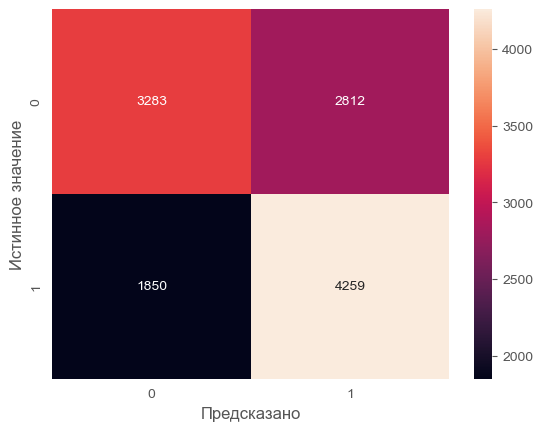

In [121]:
sns.heatmap(confusion_matrix(y_test_nn, torch.round(pred_test).detach().numpy()), annot=True, fmt='d')

plt.ylabel('Истинное значение')
plt.xlabel('Предсказано')
plt.show()

Число верных предсказания выше неправильных, класс "1" предсказан чаще верно, чем ошибочно

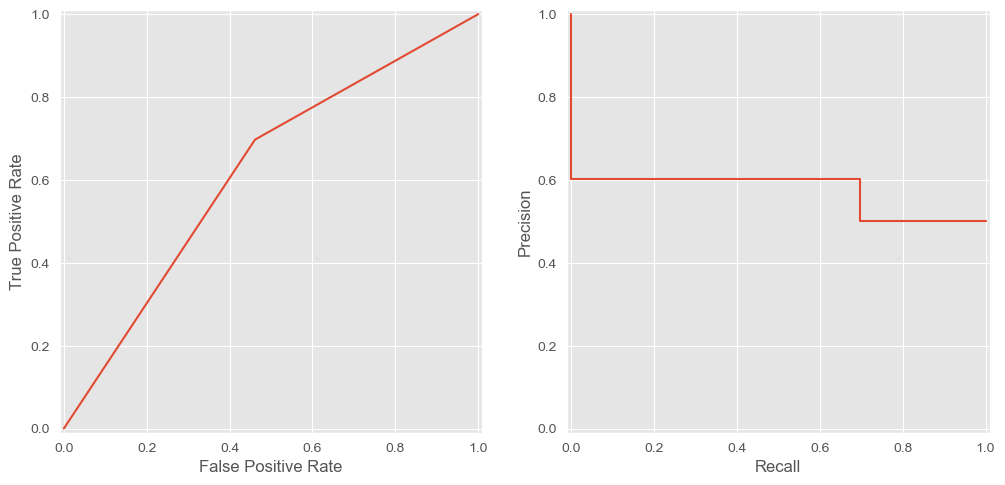

In [122]:
precision, recall, _ = precision_recall_curve(y_test, torch.round(pred_test).detach().numpy())
pr_display = PrecisionRecallDisplay(precision=precision, recall=recall)

fpr, tpr, _ = roc_curve(y_test, torch.round(pred_test).detach().numpy())
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

roc_display.plot(ax=ax1)
pr_display.plot(ax=ax2)

plt.show()

### Общий анализ признаков

Проанализируем вклад каждого признака в предсказание модели нейронной сети с помощью SHAP-анализа:

In [123]:
torch.manual_seed(42)
np.random.seed(42)

explainer = shap.DeepExplainer(net, shap.sample(X_train_nn, 2000))
shap_values = explainer(shap.sample(X_test_nn, 1000))

In [124]:
shap_values.feature_names = X_test.columns

Имеем такое соотношение:

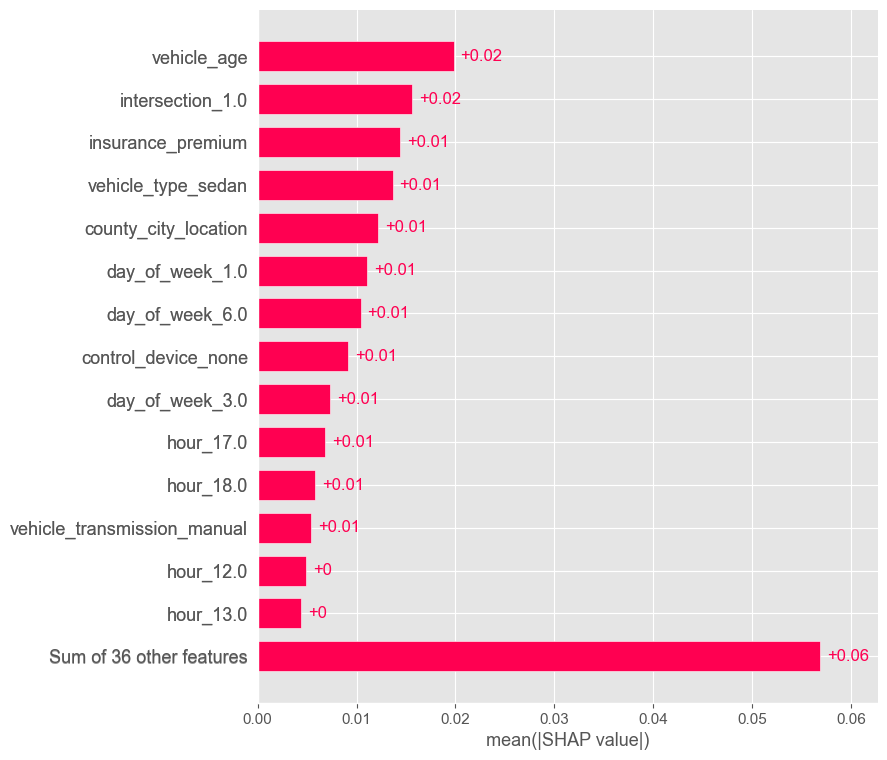

In [125]:
shap.plots.bar(shap_values[:,:,0], max_display=15) 

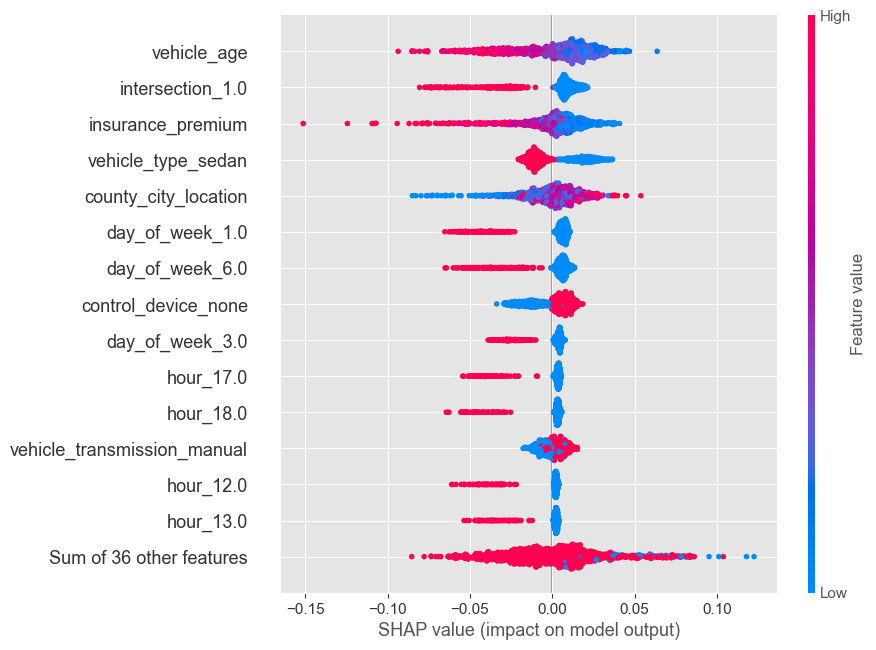

In [126]:
shap.plots.beeswarm(shap_values[:,:,0], max_display=15) 

Большинство призаков вносят небольшой вклад в предсказания, и влияют только вместе за счет количества самих признаков. Среди них несколько выделяются 2 признака: __наличие перекрестка__ и __возраст автомобиля__.

Выберем анализа один из топ-5 признаков.

### Анализ признака insurance_premium

Рассмотрим влияние на предсказание данного признака:

In [127]:
shap_values.data = np.array(shap_values.data)

C:\Users\Tomat\AppData\Local\Temp\ipykernel_7528\3128891578.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  shap_values.data = np.array(shap_values.data)


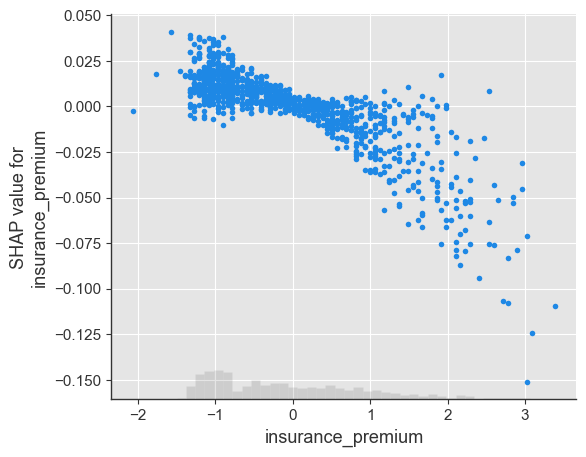

In [128]:
shap.plots.scatter(shap_values[:,'insurance_premium', 0])

Меньшие значения признака склоняют модель к более высокой вероятности отнести к классу "1". Так же среди слишком высоких значений наблюдается больший разброс шанса оказаться в аварии.

Посмотрим как ведет себя признак в датасете:

In [129]:
ins = pd.read_sql_query(
	'''
SELECT insurance_premium,
	at_fault
FROM parties
WHERE insurance_premium IS NOT NULL
''',
	con=engine)

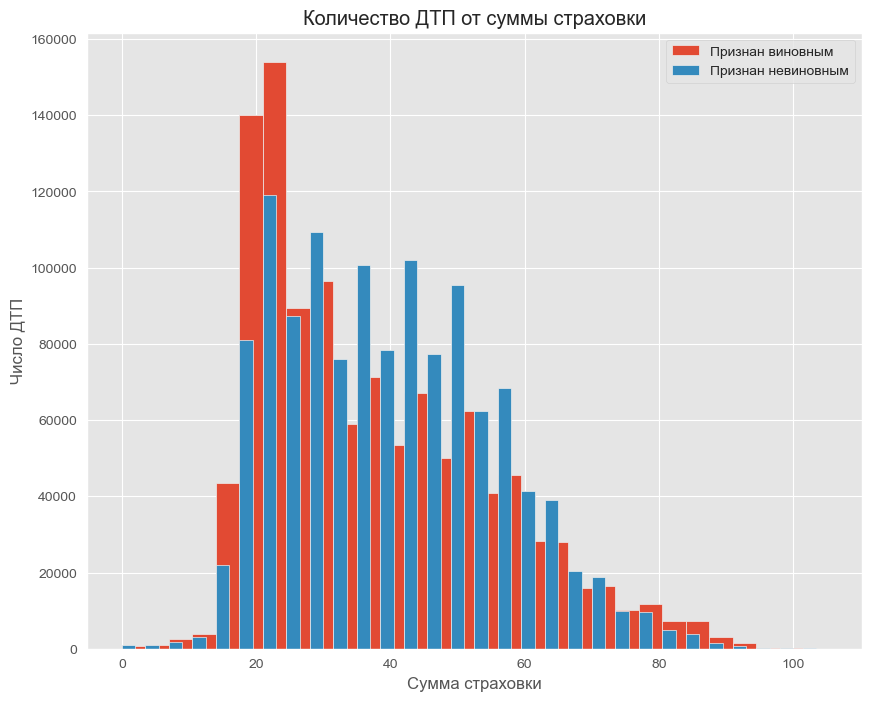

In [130]:
ax = ins.query('at_fault == 1').plot(kind='hist', bins=30, x='at_fault', figsize=(10,8))
ins.query('at_fault == 0').plot(kind='hist', bins=30, x='at_fault', ax=ax, width=2)

plt.title('Количество ДТП от суммы страховки')
plt.ylabel('Число ДТП')
plt.xlabel('Сумма страховки')
plt.legend(['Признан виновным', 'Признан невиновным'])

plt.show()

Распределение признака в БД совпадает с картиной, полученной SHAP-анализом: среди пользователей с небольшой суммой страховки или со слишком высокой число виновных выше

__Рекомендации:__ самма сумма страховки не может оказывать влияния на вероятность ДТП, это скоре зависимый фактор. Но по нему можно определить тенденции:
- высокая страховка скорее относится к дорогим автомобилям, методом снижения аварийности здесь может стать фильтрация пользователей, которым может быть доступна аренда таких машин. Задача - снизить долю пользователей с высокой долей аварий в прошлом, с низким опытом, аварийным стилем вождения и т.д.;
- низкая сумма страховки распространяется на недорогие и старые авто с историей ремонтов. Здесь возможна работа с самими автомобилями - работа над их качеством, состоянием. Это неизбежно вызовет стоимость аренды этих авто и снизит спрос, поэтому в этом направлении необходимы дополнительные исследования.

## Интенсивность ДТП

Для дополнительного анализа загрузим данные и числе ДТП по дням в течение 2009-2011 годов, за которые имеются наиболее полные данные

In [131]:
q_data = pd.read_sql_query(
	'''
SELECT collision_date,
    COUNT(DISTINCT case_id)
FROM collisions
WHERE DATE_PART('year', collision_date) BETWEEN '2009' AND '2011'
GROUP BY collision_date
''',
	con=engine)

In [132]:
q_data['collision_date'] = pd.to_datetime(q_data['collision_date'], format='%Y-%m-%d')
q_data = q_data.set_index('collision_date')

В данных нет пропусков:

In [133]:
q_data.isna().sum()

count    0
dtype: int64

### EDA

Число ДТП распределено согласно нормальному распределению

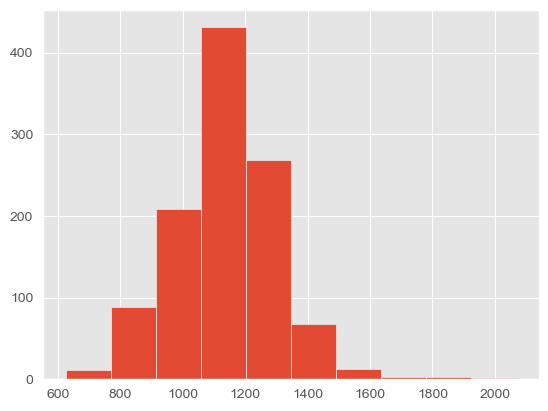

In [134]:
q_data['count'].hist()

plt.show()

In [135]:
decomposed = seasonal_decompose(q_data['count'], model="multiplicative")

Мы явно наблюдаем сезонность в данных - пик ДТП отмечается в пятницу, минимум - в воскресенье.

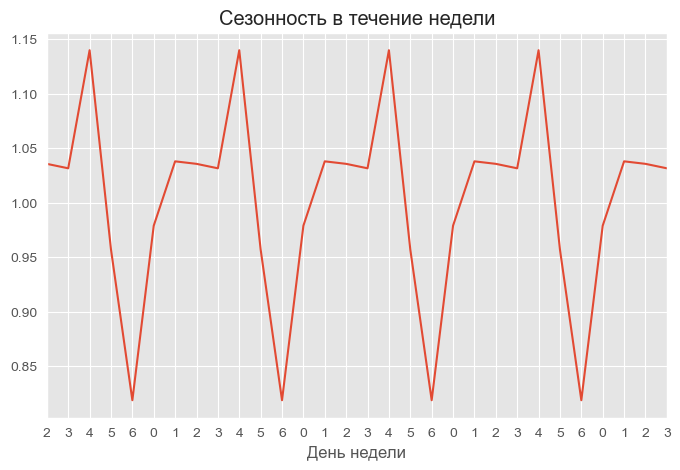

In [136]:
plt.figure(figsize=(8,5))

decomposed.seasonal['2009-04-01':'2009-04-30'].plot()

plt.title('Сезонность в течение недели')
plt.xticks(ticks=q_data['2009-04-01':'2009-04-30'].index, labels=q_data['2009-04-01':'2009-04-30'].index.dayofweek)
plt.xlabel('День недели')
plt.show()

В течение года тренд устойчив, выделяются новогодние праздники - рост в течение декабря, затем падение в ходе выходных дней

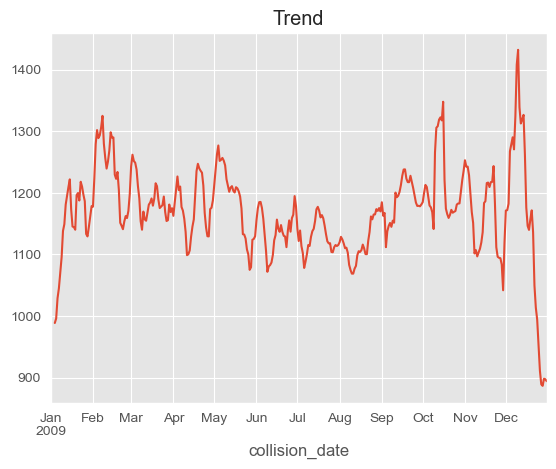

In [137]:
decomposed.trend['2009-01-01':'2009-12-31'].plot()

plt.title('Trend')
plt.show()

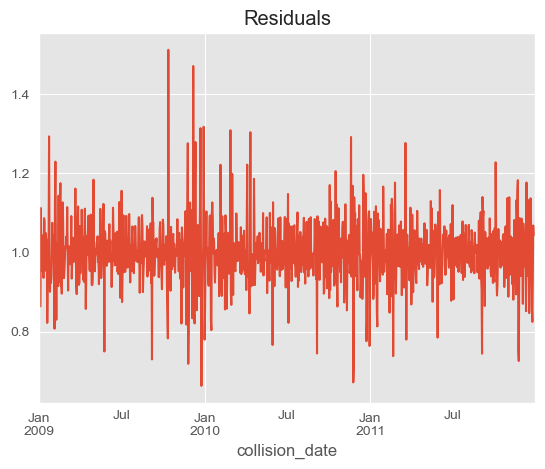

In [138]:
decomposed.resid.plot()

plt.title('Residuals')
plt.show()

### Создание признаков

In [139]:
def make_features(data, lag_list, rolling_mean_size):
    
    data['dayofweek'] = data.index.dayofweek
    data['day'] = data.index.day
    data['month'] = data.index.month

    
    for lag in lag_list:
        data[f'lag_{lag}'] = data['count'].shift(lag)

    data['rolling_mean'] = data['count'].shift(1).rolling(rolling_mean_size).mean()
    data['rolling_std'] = data['count'].shift(1).rolling(rolling_mean_size).std()
    data['num_diff'] = data['count'].shift(1) - data['count'].shift(2)

Рассмотрим автокорреляцию числа ДТП:

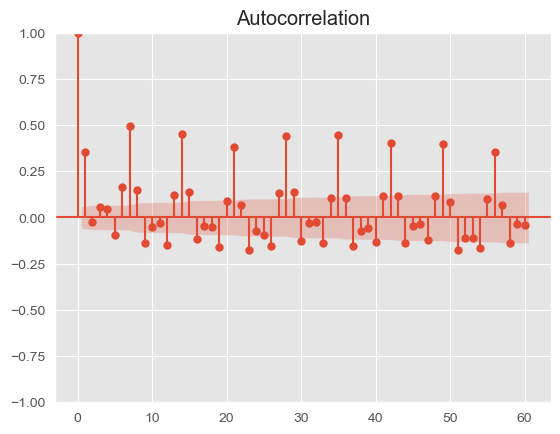

In [140]:
plot_acf(q_data['count'].squeeze(), lags=60)

plt.show()

Имеем четко наблюдаемую корреляцию в каждые семь дней. Используем эту информацию для создания новых признаков.

In [141]:
make_features(q_data, [7,14,21,28], 7)

In [142]:
q_data = q_data.dropna()

Скользящее среднее и отклонение:

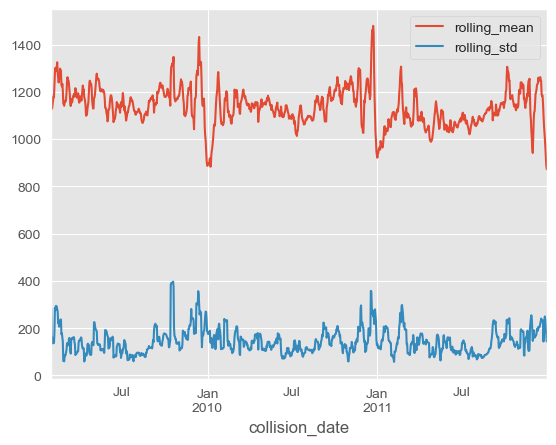

In [143]:
ax = q_data['rolling_mean'].plot()
q_data['rolling_std'].plot(ax=ax)

plt.legend()
plt.show()

Разность со сдвигом один распределна стационарно:

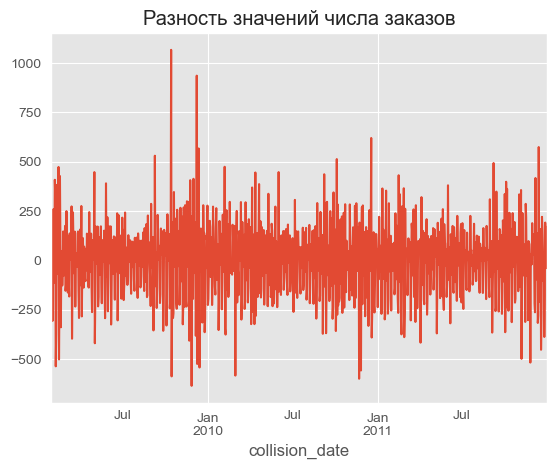

In [144]:
q_data['num_diff'].plot()

plt.title('Разность значений числа заказов')
plt.show()

### Анализ корреляции

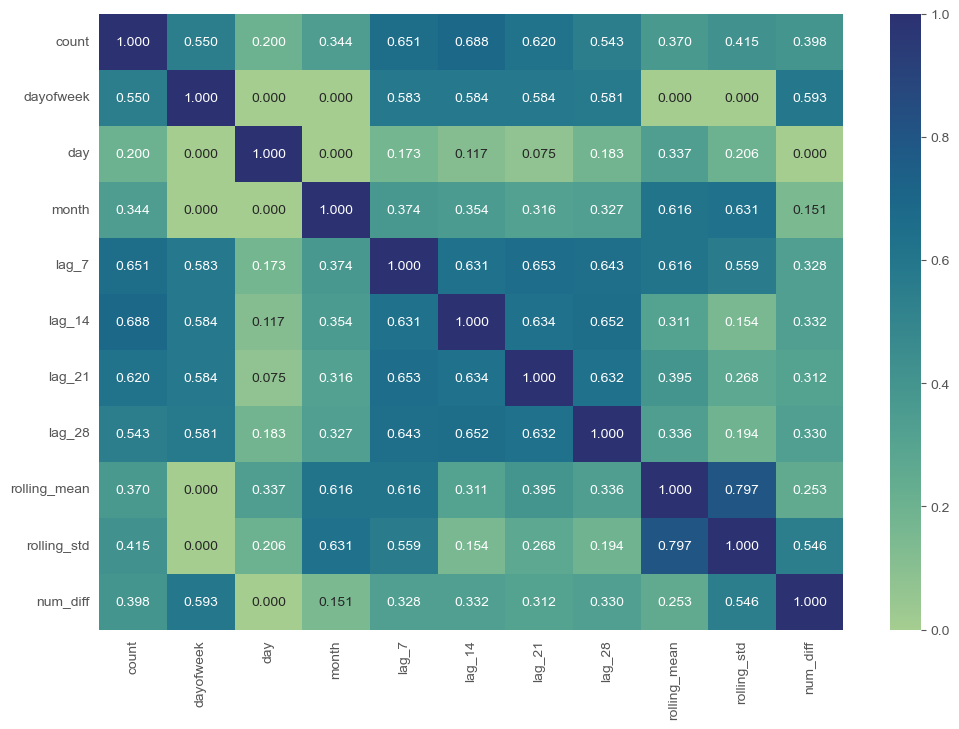

In [145]:
plt.figure(figsize=(12,8))

sns.heatmap(q_data.phik_matrix(verbose=False), annot=True, fmt='.3f', cmap='crest')

plt.show()

В целом, большинство признаков коррелирует с целевым. Однако исключим наименее значимые:

In [146]:
q_data = q_data.drop(['day', 'month', 'rolling_mean'], axis=1)

## Обучение

### Подготовка данных

In [147]:
def results(model):
    print('Лучшая модель и её параметры:\n\n', model.best_estimator_)
    print('Метрика лучшей модели на кросс-валидации:', -model.best_score_)

def best_models_stats(model):
    result = pd.DataFrame(model.cv_results_)

    result['mean_test_score'] = -result['mean_test_score']
    
    pd.set_option('display.max_colwidth', 200)

    result = result[['mean_fit_time', 'mean_score_time', 'rank_test_score', 'mean_test_score', 'params']].sort_values('rank_test_score').head(5)
    
    return result
    
    pd.reset_option('display.max_colwidth')

In [148]:
def summaries(y_test, y_test_pred, model_name):
    chars = [
        mean_squared_error(y_test, y_test_pred),
        root_mean_squared_error(y_test, y_test_pred),
        mean_absolute_error(y_test, y_test_pred),
        r2_score(y_test, y_test_pred),
        mean_absolute_percentage_error(y_test, y_test_pred)
    ]
    
    return pd.DataFrame(
        data=chars,
        index=['MSE(Среднеквадратичная ошибка)',
               'RMSE(Корень среднеквадратичной ошибки)',
               'MAE(Средняя абсолютная ошибка)', 'R2-score(R2-мера)',
               'MAPE'
              ],
        columns=['Значение параметра']).rename_axis(f'Параметр модели "{model_name}"', axis=1)

Разобьем данные на выборки

In [149]:
X_train, X_test, y_train, y_test = data_split(q_data, target='count', TEST_SIZE=0.2, shuffle=False)

Наименования колонок:

In [150]:
num_columns = ['lag_7', 'lag_14', 'lag_21', 'lag_28', 'rolling_std', 'num_diff']
ohe_columns = ['dayofweek']

Проведем кросс-валидацию. Для этого подготовим пайплайн:

In [151]:
ohe_pipe = Pipeline(
    [
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
    )

In [152]:
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('num', StandardScaler(), num_columns)
    ], 
    remainder='passthrough'
)

In [153]:
final_pipe = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeRegressor())
])

In [154]:
param_grid = [
    {
        'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 10),
        'models__max_features': range(2, 10),
        'preprocessor__num': [StandardScaler(), 'passthrough']
    },
    
    {
        'models': [KNeighborsRegressor()],
        'models__n_neighbors': range(2, 8),
        'models__metric': ['euclidean', 'manhattan', 'minkowski'],
        'models__weights': ['uniform', 'distance'],
        'preprocessor__num': [StandardScaler(), 'passthrough']
    },

    {
        'models': [LinearRegression()],
        'preprocessor__num': [StandardScaler(), 'passthrough']
    }
]

### Кросс-валидация

In [155]:
randomized_search = RandomizedSearchCV(
    final_pipe, 
    param_grid, 
    cv=TimeSeriesSplit(),
    scoring='neg_mean_absolute_error',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [156]:
randomized_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'models': [DecisionTreeR...ndom_state=42)], 'models__max_depth': range(2, 10), 'models__max_features': range(2, 10), 'preprocessor__num': [StandardScaler(), 'passthrough']}, {'models': [KNeighborsRegressor()], 'models__metric': ['euclidean', 'manhattan', ...], 'models__n_neighbors': range(2, 8), 'models__weights': ['uniform', 'distance'], ...}, ...]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` i

In [157]:
results(randomized_search)

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['dayofweek']),
                                                 ('num', StandardScaler(),
                                                  ['lag_7', 'lag_14', 'lag_21',
                                                   'lag_28', 'rolling_std',
                                                   'num_diff'])])),
                ('models',
                 KNeighborsRegressor(metric='

In [158]:
best_model = randomized_search.best_estimator_

In [159]:
best_models_stats(randomized_search)

,mean_fit_time,mean_score_time,rank_test_score,mean_test_score,params
7,0.012511,0.009196,1,99.991348,"{'preprocessor__num': StandardScaler(), 'models__weights': 'uniform', 'models__n_neighbors': 7, 'models__metric': 'manhattan', 'models': KNeighborsRegressor()}"
1,0.011789,0.005446,2,102.635406,"{'preprocessor__num': 'passthrough', 'models__max_features': 9, 'models__max_depth': 2, 'models': DecisionTreeRegressor(random_state=42)}"
2,0.014882,0.005544,3,104.079989,"{'preprocessor__num': StandardScaler(), 'models__max_features': 9, 'models__max_depth': 3, 'models': DecisionTreeRegressor(random_state=42)}"
9,0.008449,0.004614,4,104.140183,"{'preprocessor__num': 'passthrough', 'models__max_features': 8, 'models__max_depth': 4, 'models': DecisionTreeRegressor(random_state=42)}"
4,0.012287,0.009879,5,105.572324,"{'preprocessor__num': StandardScaler(), 'models__weights': 'distance', 'models__n_neighbors': 4, 'models__metric': 'minkowski', 'models': KNeighborsRegressor()}"


Метрики лучшей модели на трейне:

In [160]:
y_train_pred = best_model.predict(X_train)

In [161]:
summaries(y_train, y_train_pred, 'KNeighborsRegressor')

"Параметр модели ""KNeighborsRegressor""",Значение параметра
MSE(Среднеквадратичная ошибка),13411.633586
RMSE(Корень среднеквадратичной ошибки),115.808608
MAE(Средняя абсолютная ошибка),82.375984
R2-score(R2-мера),0.512703
MAPE,0.073569


### Тестирование

Для сравнения результатов будем использовать модель, дающую медиану для каждого значения:

In [162]:
check_model = DummyRegressor(strategy='median')

In [163]:
check_model.fit(X_train, y_train)

,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'median'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None


In [164]:
check_result = check_model.predict(y_test)

In [165]:
sum_dum = summaries(y_test, check_result, model_name='Наивная модель(медиана)')
sum_dum

"Параметр модели ""Наивная модель(медиана)""",Значение параметра
MSE(Среднеквадратичная ошибка),25791.378505
RMSE(Корень среднеквадратичной ошибки),160.596944
MAE(Средняя абсолютная ошибка),122.556075
R2-score(R2-мера),-0.021438
MAPE,0.117770


__Метрики модели на тесте__:

In [166]:
y_test_pred = best_model.predict(X_test)

In [167]:
summaries(y_test, y_test_pred, 'KNeighborsRegressor')

"Параметр модели ""KNeighborsRegressor""",Значение параметра
MSE(Среднеквадратичная ошибка),14372.166317
RMSE(Корень среднеквадратичной ошибки),119.883970
MAE(Средняя абсолютная ошибка),87.153538
R2-score(R2-мера),0.430807
MAPE,0.081758


Графическое отображение:

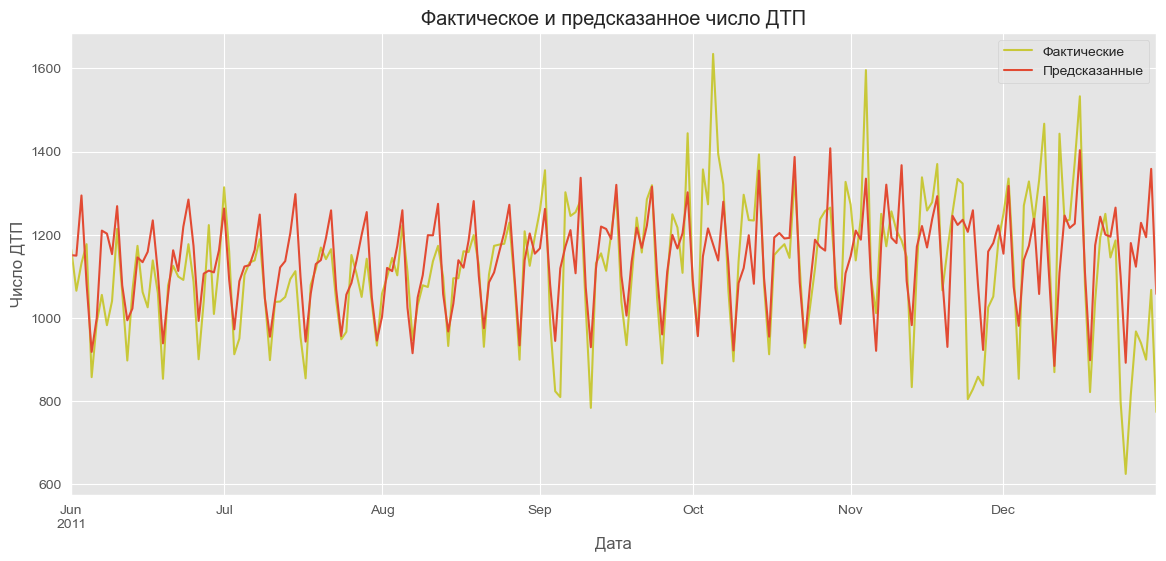

In [168]:
ax = y_test.plot(figsize=(14,6), rot=0, alpha=0.75, color='y')
pd.Series(data=y_test_pred, name='pred_y', index=y_test.index).plot(ax=ax)

plt.title('Фактическое и предсказанное число ДТП')
plt.ylabel('Число ДТП')
plt.xlabel('Дата')

plt.legend(['Фактические','Предсказанные'])
plt.show()

__Вывод:__ из имеющихся данных о ДТП мы провели агрегацию по дням. На основе этих данных был проведен анализ и графически отображены закономерности. Используя эту информацию были сгенерированы новые признаки, с использованием которых была проведена кросс-валидация для определения лучшей модели. Лучшей моделью оказалась модель k ближайших соседей - ее метрики выше наивной модели, а на графике видно, что модели удалось уловить цикличность в данных - кроме отдельных участков выбросов.

## Выводы

В ходе работы мы подключились к базе данных каршеринговой компании и проанализировали информацию о ДТП, в которых принимали участие арендаторы автомобилей компании. На основании имеющихся данных мы разработали несколько моделей, предсказывающих, станет ли водитель виновником ДТП.

Целевой метрикой была выбрана f1-мера - так как для нас важно соблюсти баланс между полнотой и точностью модели.

В результате все рассмотренные модели не смогли дать высокий результат метрики.

В ходе анализа значений метрик лучшей моделью показала себя нейронная сеть со следующими параметрами: 
- 1-й скрытый слой, 40 нейронов
- 2-й скрытый слой, 20 нейрона
- 3-й скрытый слой, 40 нейронов
- 4-й скрытый слой, 10 нейрона.

Из анализа работы ясно, что сделать модель, точно предсказывающую ДТП, невозможно из-за независимых причин. Факторы, более всего влияющие на метрику, - наличие на маршруте перекрестка и возраст авто. Одним из вариантов снижения аварийности может предупреждение о наличие перекрестков на маршруте движения.

__Рекомендации по работе модели:__ для улучшения работы модели и повышения адекватности предсказаний стоит провести работу в 2 направлениях:
- расширить перечень собираемых признаков, чтобы найти какие-то дополнительные, в т.ч. скрытые корреляции;
- изменить набор входных данных для предсказанния. Вместо предсказания по историческим данным о ДТП стоит строить предсказания на совокупности всех данных о поездках, как аварийных, так и без. Целевым признаком здесь так же будет виновность в аварии at_fault, при этом аварии, виновником в которых водители-аренаторы не были признаны из набора данных необходимо исключить ввиду сложности предсказания и отсутствия прямых корреляций с таргетом. 

Дополнительно был проведен анализ частоты происшествия ДТП с использованием исторических данных за наиболее полный период (2009-2011 гг). Используя эту информацию при помощи кросс-валидации была определена модель, способная выполнять предсказание о количестве происшествий в следующий день с достаточной точностью.